# <span style="color:red; font-weight:bold">MSE loss for DL models + XGBoost(No quantile)</span>

## <span style="color:orange; font-weight:bold"> Validation stage (train vs val_1)</span>

### Import dataset

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("wandb_mse_updated.csv")

# Concatenate the TFT runs
# df_TFT = pd.read_csv("TFT_mse.csv", usecols=[c for c in df.columns if c in pd.read_csv("TFT_mse.csv", nrows=0).columns])
# # Reindex df2 to ensure it has exactly the same columns/order as df1
# df_TFT = df_TFT.reindex(columns=df.columns)
# df = pd.concat([df, df_TFT], ignore_index=True)


# === Keep only validation stage runs ===
df_val = df[df['testing_stage'] == False].copy()

### Boxplots of the forecasters

ValueError: Axis limits cannot be NaN or Inf

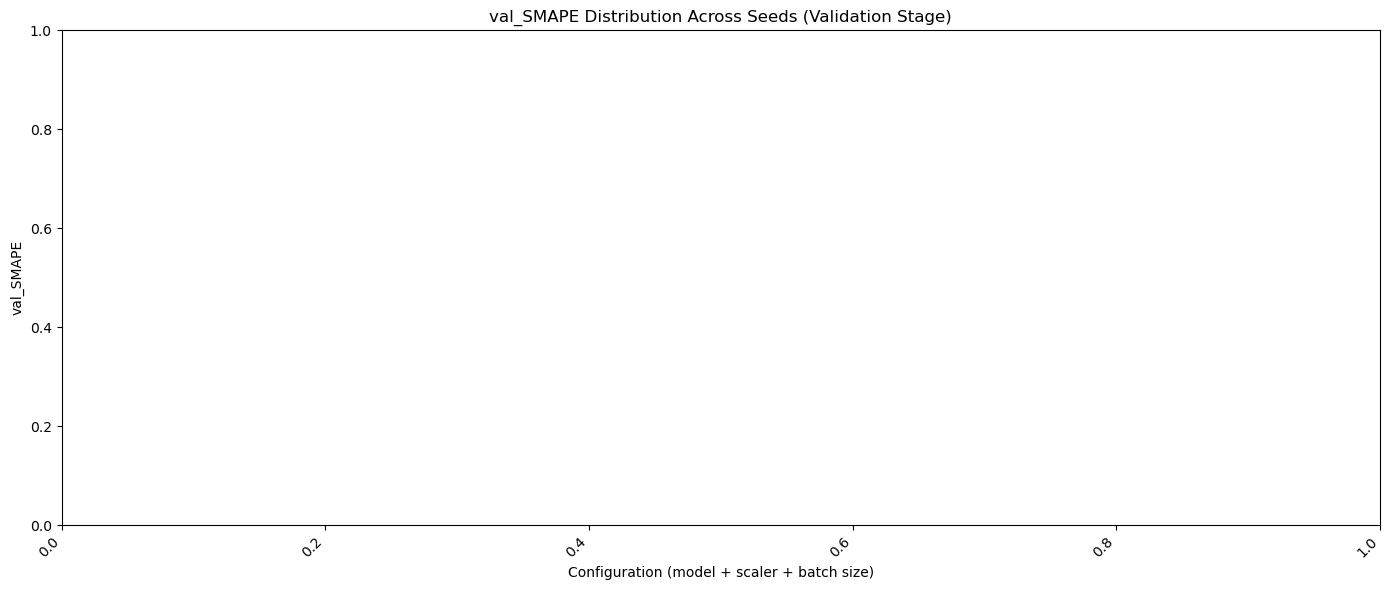

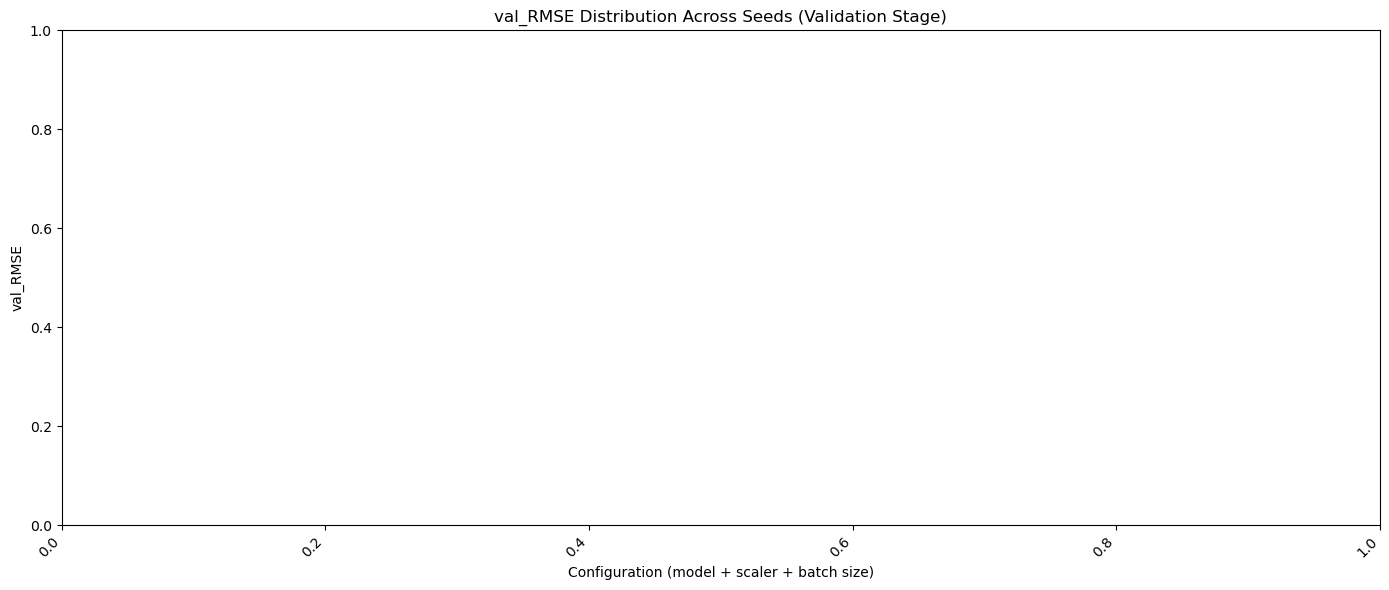

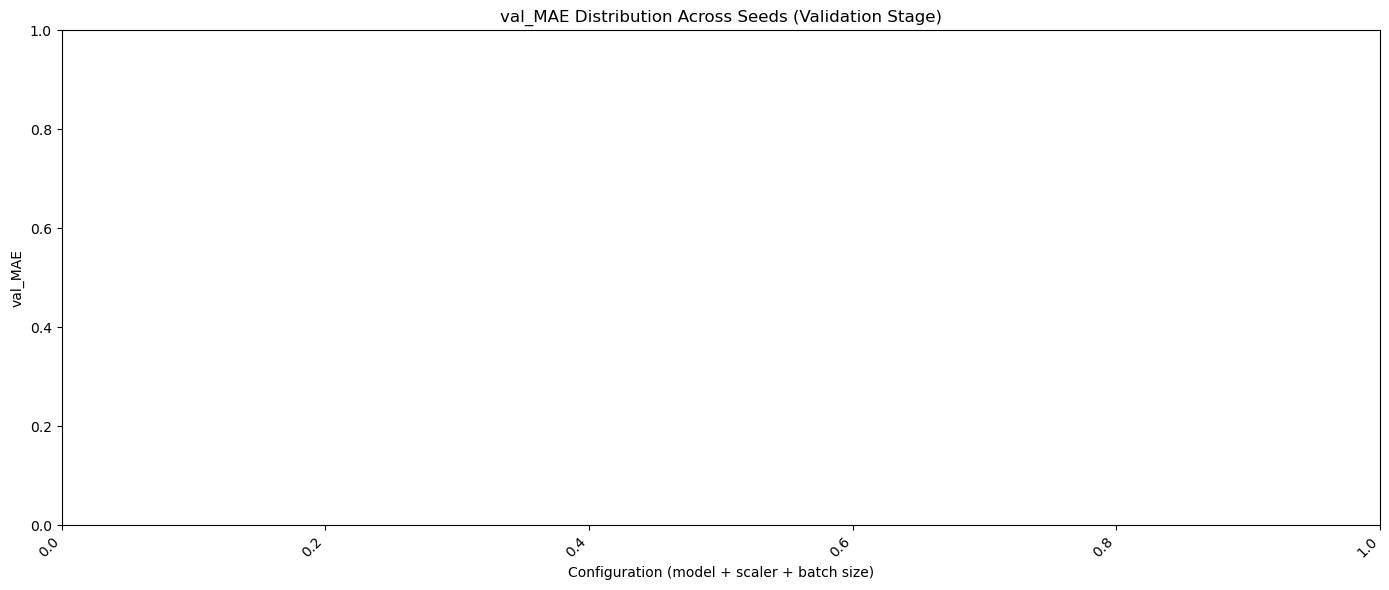

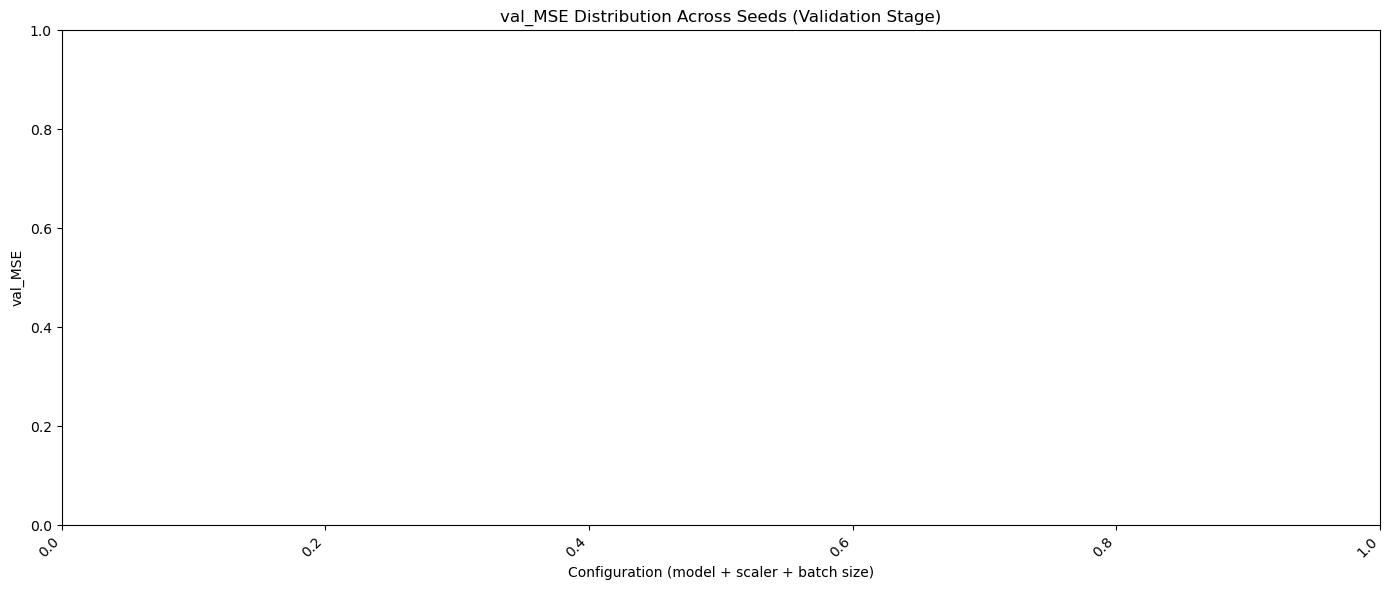

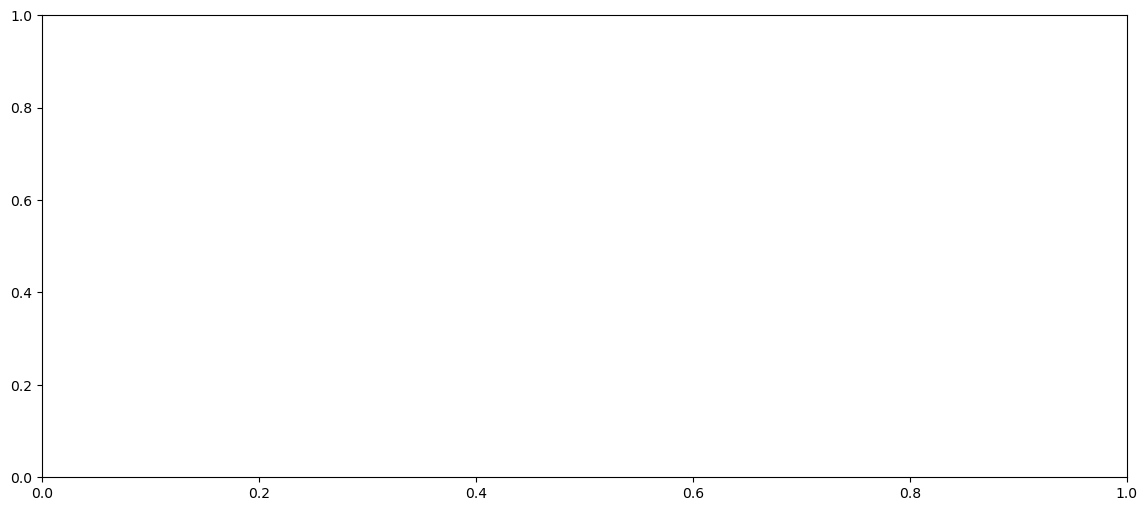

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_boxplots(metric, df):
    # Create config name
    df['config_name'] = (
        df['model_name'] + '-' +
        df['scaler_name'] + '-bs' +
        df['batch_size'].astype(str)
    )

    # Sort configs by mean metric
    order = df.groupby('config_name')[metric].mean().sort_values().index
    mean_vals = df.groupby('config_name')[metric].mean()

    # Plot
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df, x='config_name', y=metric, order=order, palette='Set2')

    # Annotate means
    y_min = df[metric].min()
    y_max = df[metric].max()
    y_range = y_max - y_min
    offset = 0.02 * y_range

    for i, config in enumerate(order):
        mean_val = mean_vals[config]
        plt.text(i, mean_val + offset, f"{mean_val:.2f}",
                 ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')

    # Adjust y-axis for R2
    if metric.lower() == 'val_r2':
        plt.ylim(y_min - 0.05 * y_range, y_max + 0.05 * y_range)

    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Configuration (model + scaler + batch size)")
    plt.ylabel(f"{metric}")
    plt.title(f"{metric} Distribution Across Seeds (Validation Stage)")
    plt.tight_layout()
    # plt.show()
    plt.savefig(f"Plots/boxplot_{metric}_mse_validation.png")



metrics = ['val_SMAPE', 'val_RMSE', 'val_MAE', 'val_MSE', 'val_R2']
for metric in metrics:
    plot_boxplots(metric, df_val)

In [25]:
print("The best configurations (based on SMAPE) are:")
print("1. Model: XGBoost, Scaler: StandardScaler")
print("2. Model: LSTM, Scaler: StandardScaler, Batch Size: 16")
print("3. Model: LSTM, Scaler: Min-Max, Batch Size: 16")
print("4. Model: BiLSTM, Scaler: StandardScaler, Batch Size: 16")
print("5. Model: BiLSTM, Scaler: StandardScaler, Batch Size: 32")
print("6. Model: TFT, Scaler: StandardScaler, Batch Size: 16")

The best configurations (based on SMAPE) are:
1. Model: XGBoost, Scaler: StandardScaler
2. Model: LSTM, Scaler: StandardScaler, Batch Size: 16
3. Model: LSTM, Scaler: Min-Max, Batch Size: 16
4. Model: BiLSTM, Scaler: StandardScaler, Batch Size: 16
5. Model: BiLSTM, Scaler: StandardScaler, Batch Size: 32
6. Model: TFT, Scaler: StandardScaler, Batch Size: 16


### heatmap of metrics vs forecasters

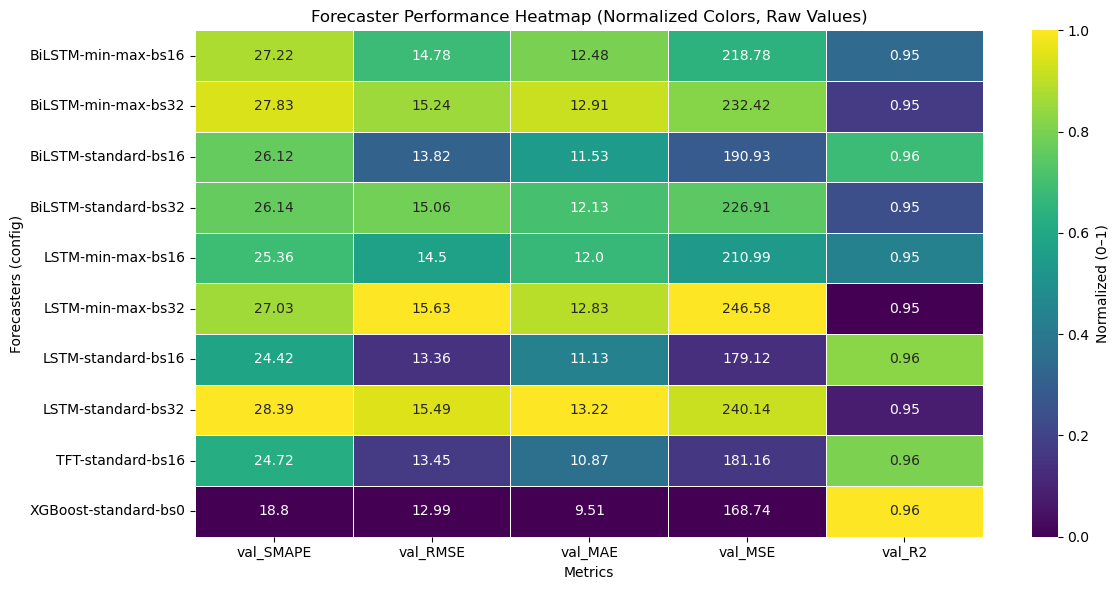

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create config_name if needed
df_val['config_name'] = df_val['model_name'] + '-' + df_val['scaler_name'] + '-bs' + df_val['batch_size'].astype(str)

# 2. Metrics and average values
metrics = ['val_SMAPE', 'val_RMSE', 'val_MAE', 'val_MSE', 'val_R2']
heatmap_data = df_val.groupby('config_name')[metrics].mean()

# 3. Normalize for coloring
normalized = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

# 4. Plot heatmap
plt.figure(figsize=(12, len(heatmap_data) * 0.6))
sns.heatmap(
    normalized,
    annot=heatmap_data.round(2),  # show real values
    fmt='',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Normalized (0–1)'},
)

plt.title("Forecaster Performance Heatmap (Normalized Colors, Raw Values)")
plt.xlabel("Metrics")
plt.ylabel("Forecasters (config)")
plt.tight_layout()
# plt.show()
plt.savefig(f"Plots/heatmap_mse_validation.png")


## <span style="color:blue; font-weight:bold"> Testing stage (train+val_1 vs test)</span>

### Import dataset

In [7]:
import numpy as np
import pandas as pd

df = pd.read_csv("wandb_mse_updated.csv")

# Concatenate the TFT runs
# df_TFT = pd.read_csv("TFT_mse.csv", usecols=[c for c in df.columns if c in pd.read_csv("TFT_mse.csv", nrows=0).columns])
# # Reindex df2 to ensure it has exactly the same columns/order as df1
# df_TFT = df_TFT.reindex(columns=df.columns)
# df = pd.concat([df, df_TFT], ignore_index=True)


df_test = df[
    (df['testing_stage'] == True) &         # Only test stage runs
    (df['data_augmentation'] == False)      # Only non-augmented runs
].copy()

### Boxplots of the forecasters

/tmp/ipykernel_554901/2240485928.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_554901/2240485928.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_554901/2240485928.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_554901/2240485928.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_554901/2240485928.py:25: FutureWa

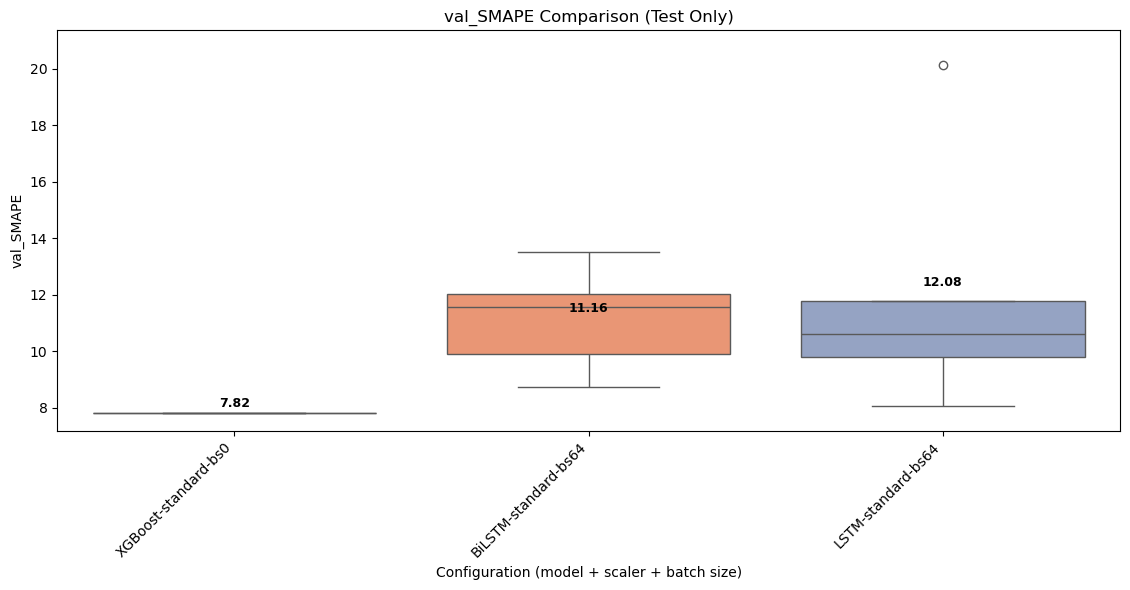

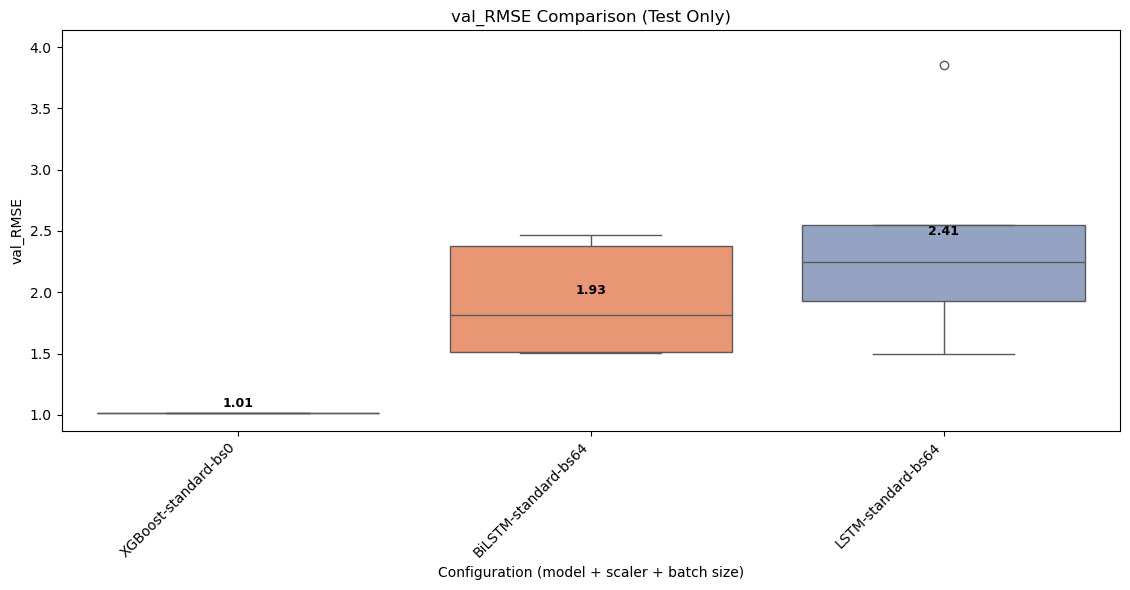

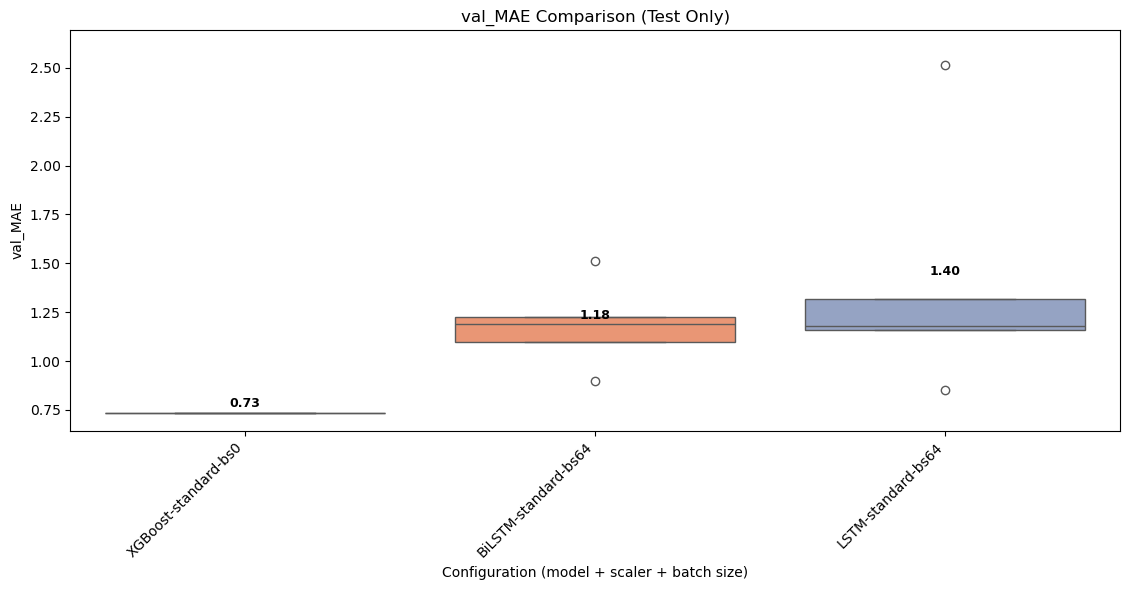

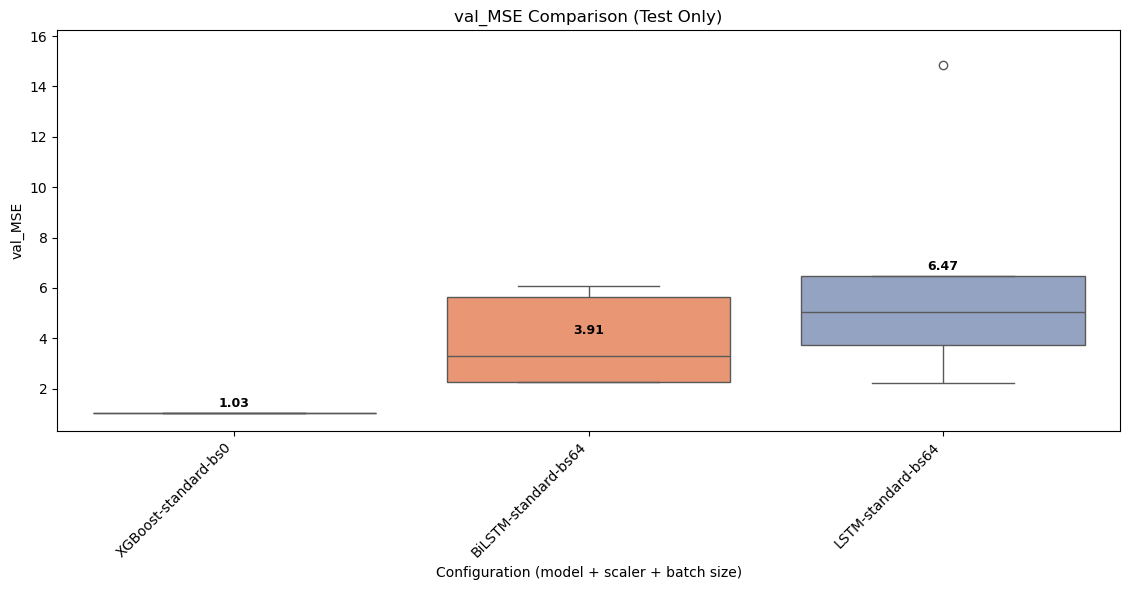

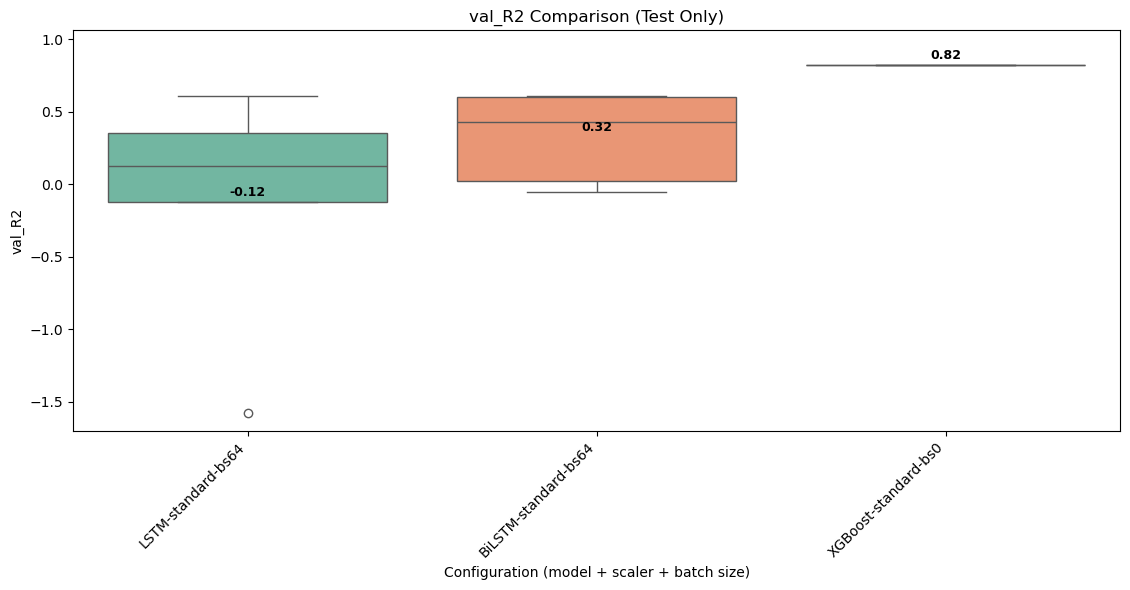

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_test_boxplots(metric, df_test):
    # Build config_name
    df_test = df_test.copy()
    df_test['config_name'] = (
        df_test['model_name'] + '-' +
        df_test['scaler_name'] + '-bs' +
        df_test['batch_size'].astype(str)
    )

    # Order configurations by mean metric value
    order = df_test.groupby('config_name')[metric].mean().sort_values().index

    # Compute offset for annotations
    y_min = df_test[metric].min()
    y_max = df_test[metric].max()
    y_range = y_max - y_min
    offset = 0.01 * y_range

    # Plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df_test,
        x='config_name',
        y=metric,
        order=order,
        palette='Set2'
    )

    # Add mean annotations
    grouped = df_test.groupby('config_name')[metric].mean()
    for i, config in enumerate(order):
        val = grouped[config]
        plt.text(
            i, val + offset, f"{val:.2f}",
            ha='center', va='bottom', fontsize=9,
            color='black', fontweight='bold'
        )

    # Labels and layout
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Configuration (model + scaler + batch size)")
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison (Test Only)")
    plt.ylim(y_min - 0.05 * y_range, y_max + 0.1 * y_range)
    plt.tight_layout(rect=[0, 0, 0.95, 1])

    # Save
    plt.savefig(f"Plots/boxplot_{metric}_test_only.png")
    # plt.show()c

# Run for all metrics
metrics = ['val_SMAPE', 'val_RMSE', 'val_MAE', 'val_MSE', 'val_R2']
for metric in metrics:
    plot_test_boxplots(metric, df_test)

### heatmap of metrics vs forecasters

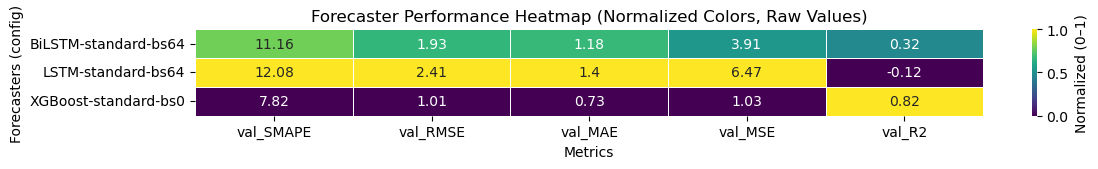

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create config_name if needed
df_test['config_name'] = df_test['model_name'] + '-' + df_test['scaler_name'] + '-bs' + df_test['batch_size'].astype(str)

# 2. Metrics and average values
metrics = ['val_SMAPE', 'val_RMSE', 'val_MAE', 'val_MSE', 'val_R2']
heatmap_data = df_test.groupby('config_name')[metrics].mean()

# 3. Normalize for coloring
normalized = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

# 4. Plot heatmap
plt.figure(figsize=(12, len(heatmap_data) * 0.6))
sns.heatmap(
    normalized,
    annot=heatmap_data.round(2),  # show real values
    fmt='',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Normalized (0–1)'},
)

plt.title("Forecaster Performance Heatmap (Normalized Colors, Raw Values)")
plt.xlabel("Metrics")
plt.ylabel("Forecasters (config)")
plt.tight_layout()
# plt.show()
plt.savefig(f"Plots/heatmap_mse_testing.png")


## <span style="color:green; font-weight:bold"> Data Augmentation stage</span>

### Import dataset

In [10]:
import pandas as pd

df = pd.read_csv("wandb_mse_updated.csv")

# Concatenate the TFT runs
# df_TFT = pd.read_csv("TFT_mse.csv", usecols=[c for c in df.columns if c in pd.read_csv("TFT_mse.csv", nrows=0).columns])
# # Reindex df2 to ensure it has exactly the same columns/order as df1
# df_TFT = df_TFT.reindex(columns=df.columns)
# df = pd.concat([df, df_TFT], ignore_index=True)

# df_aug = df[
#     (df['testing_stage'] == True) &         # Only test stage runs
#     (df['data_augmentation'] == True)       # Only augmented runs
# ].copy()

### Compute Lift metric plots

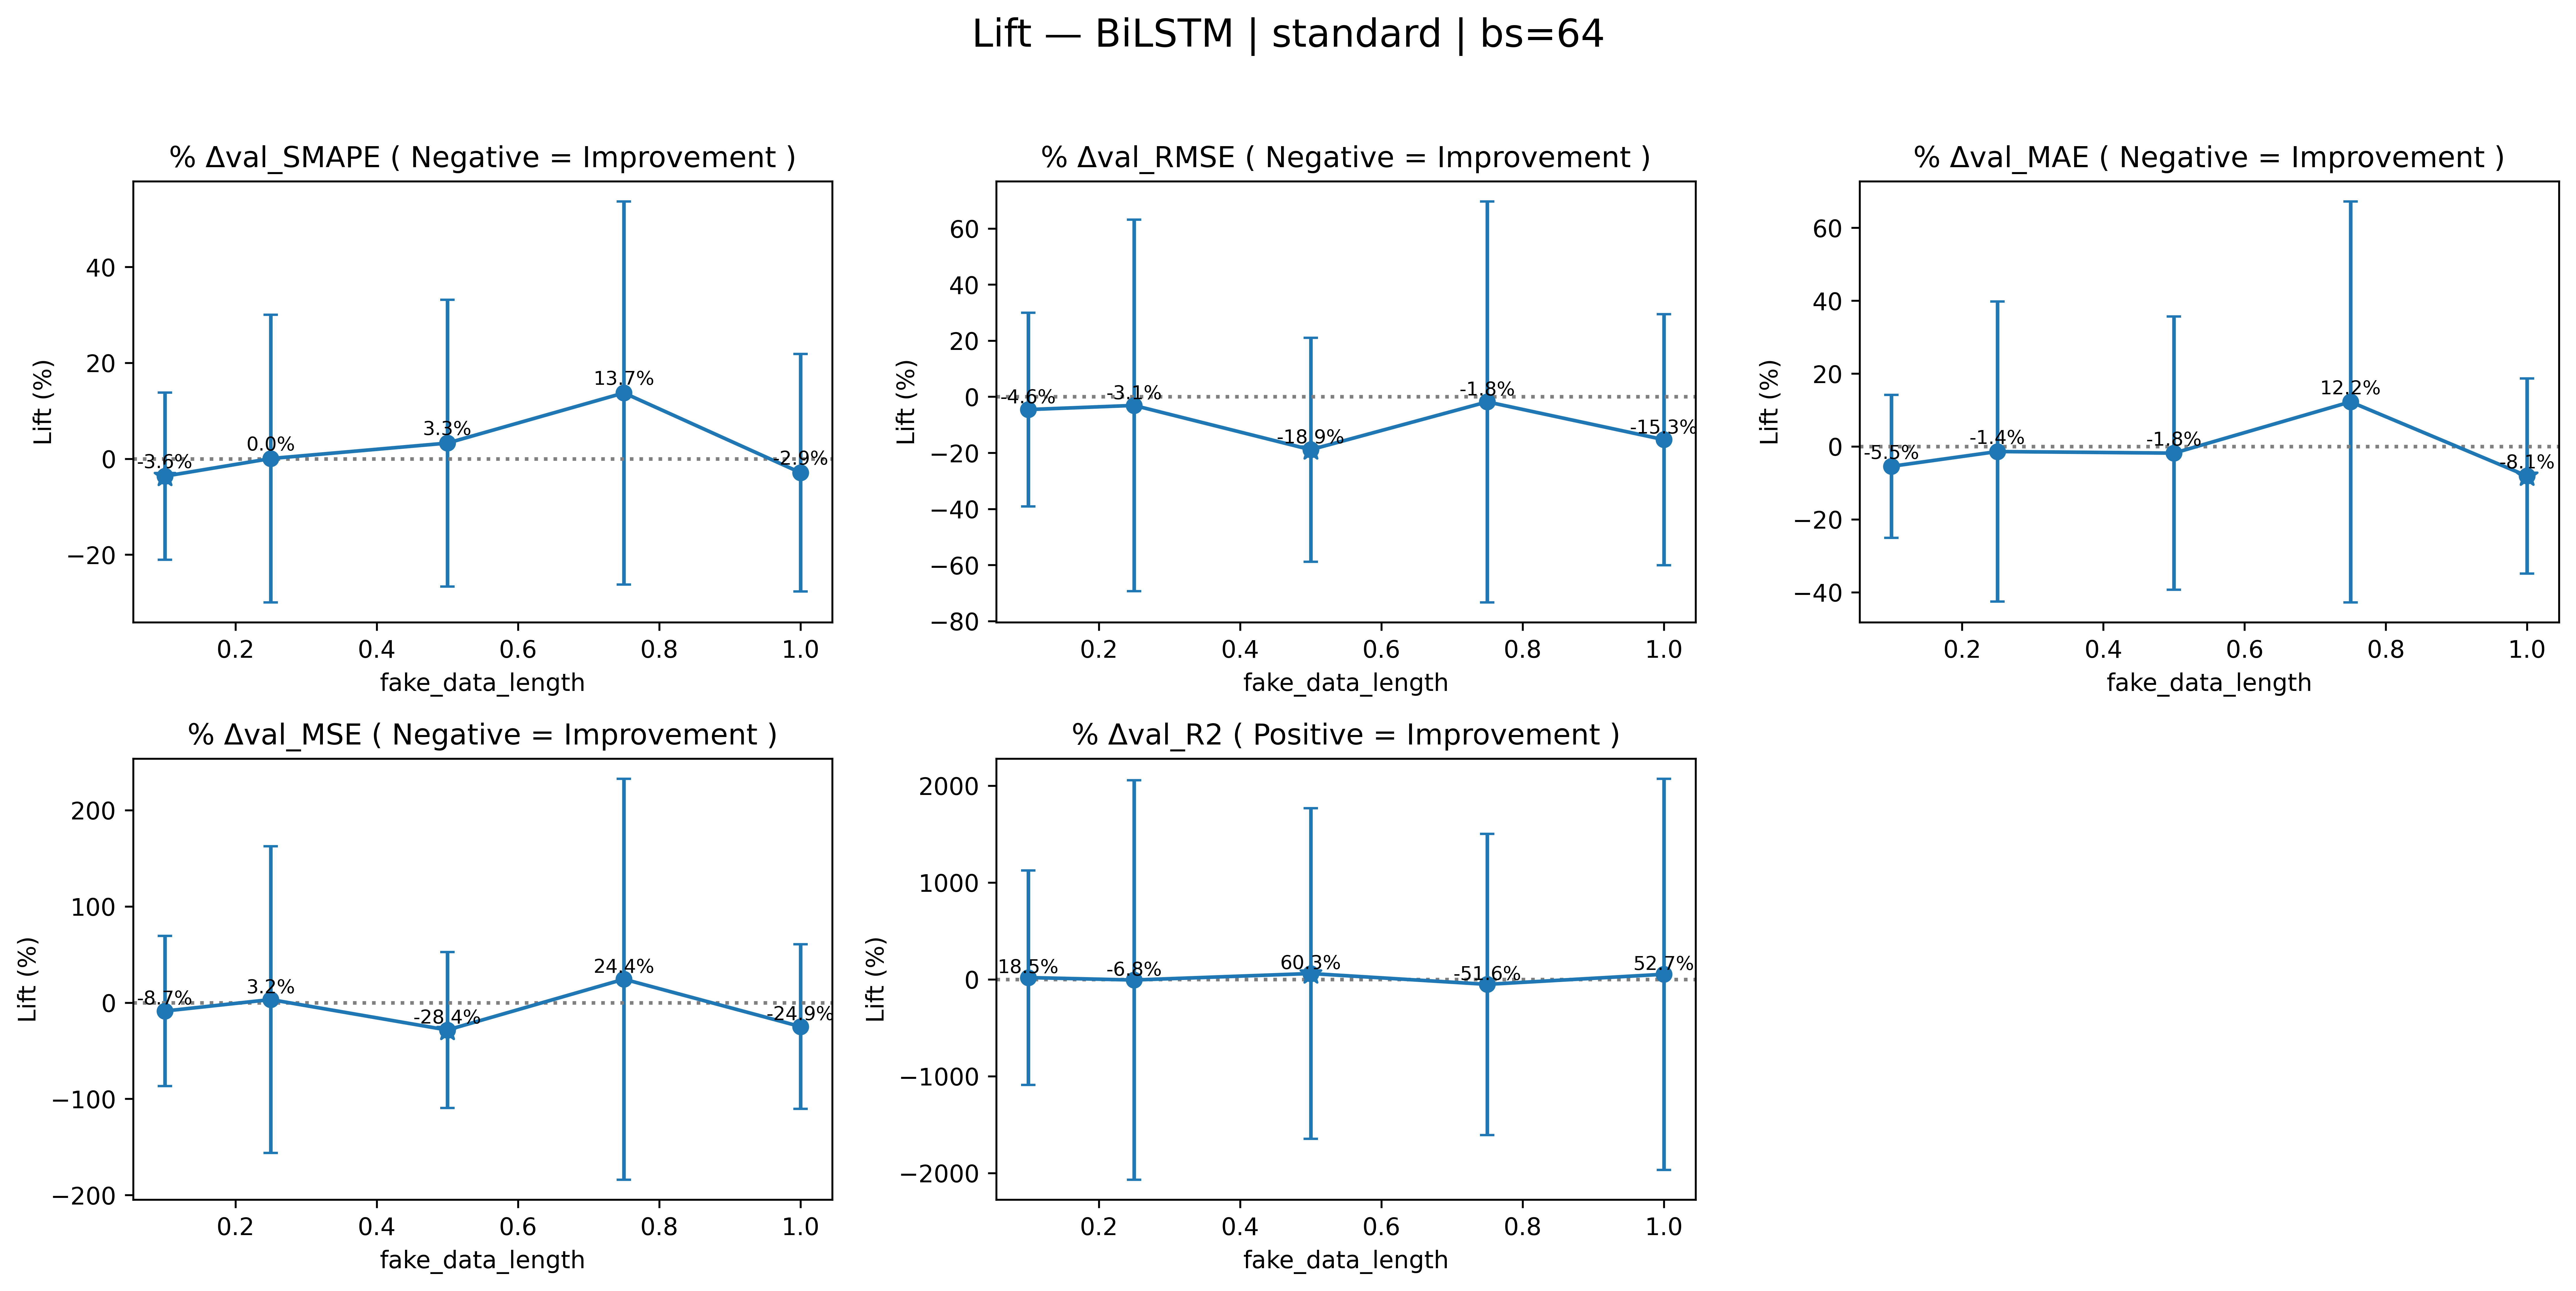

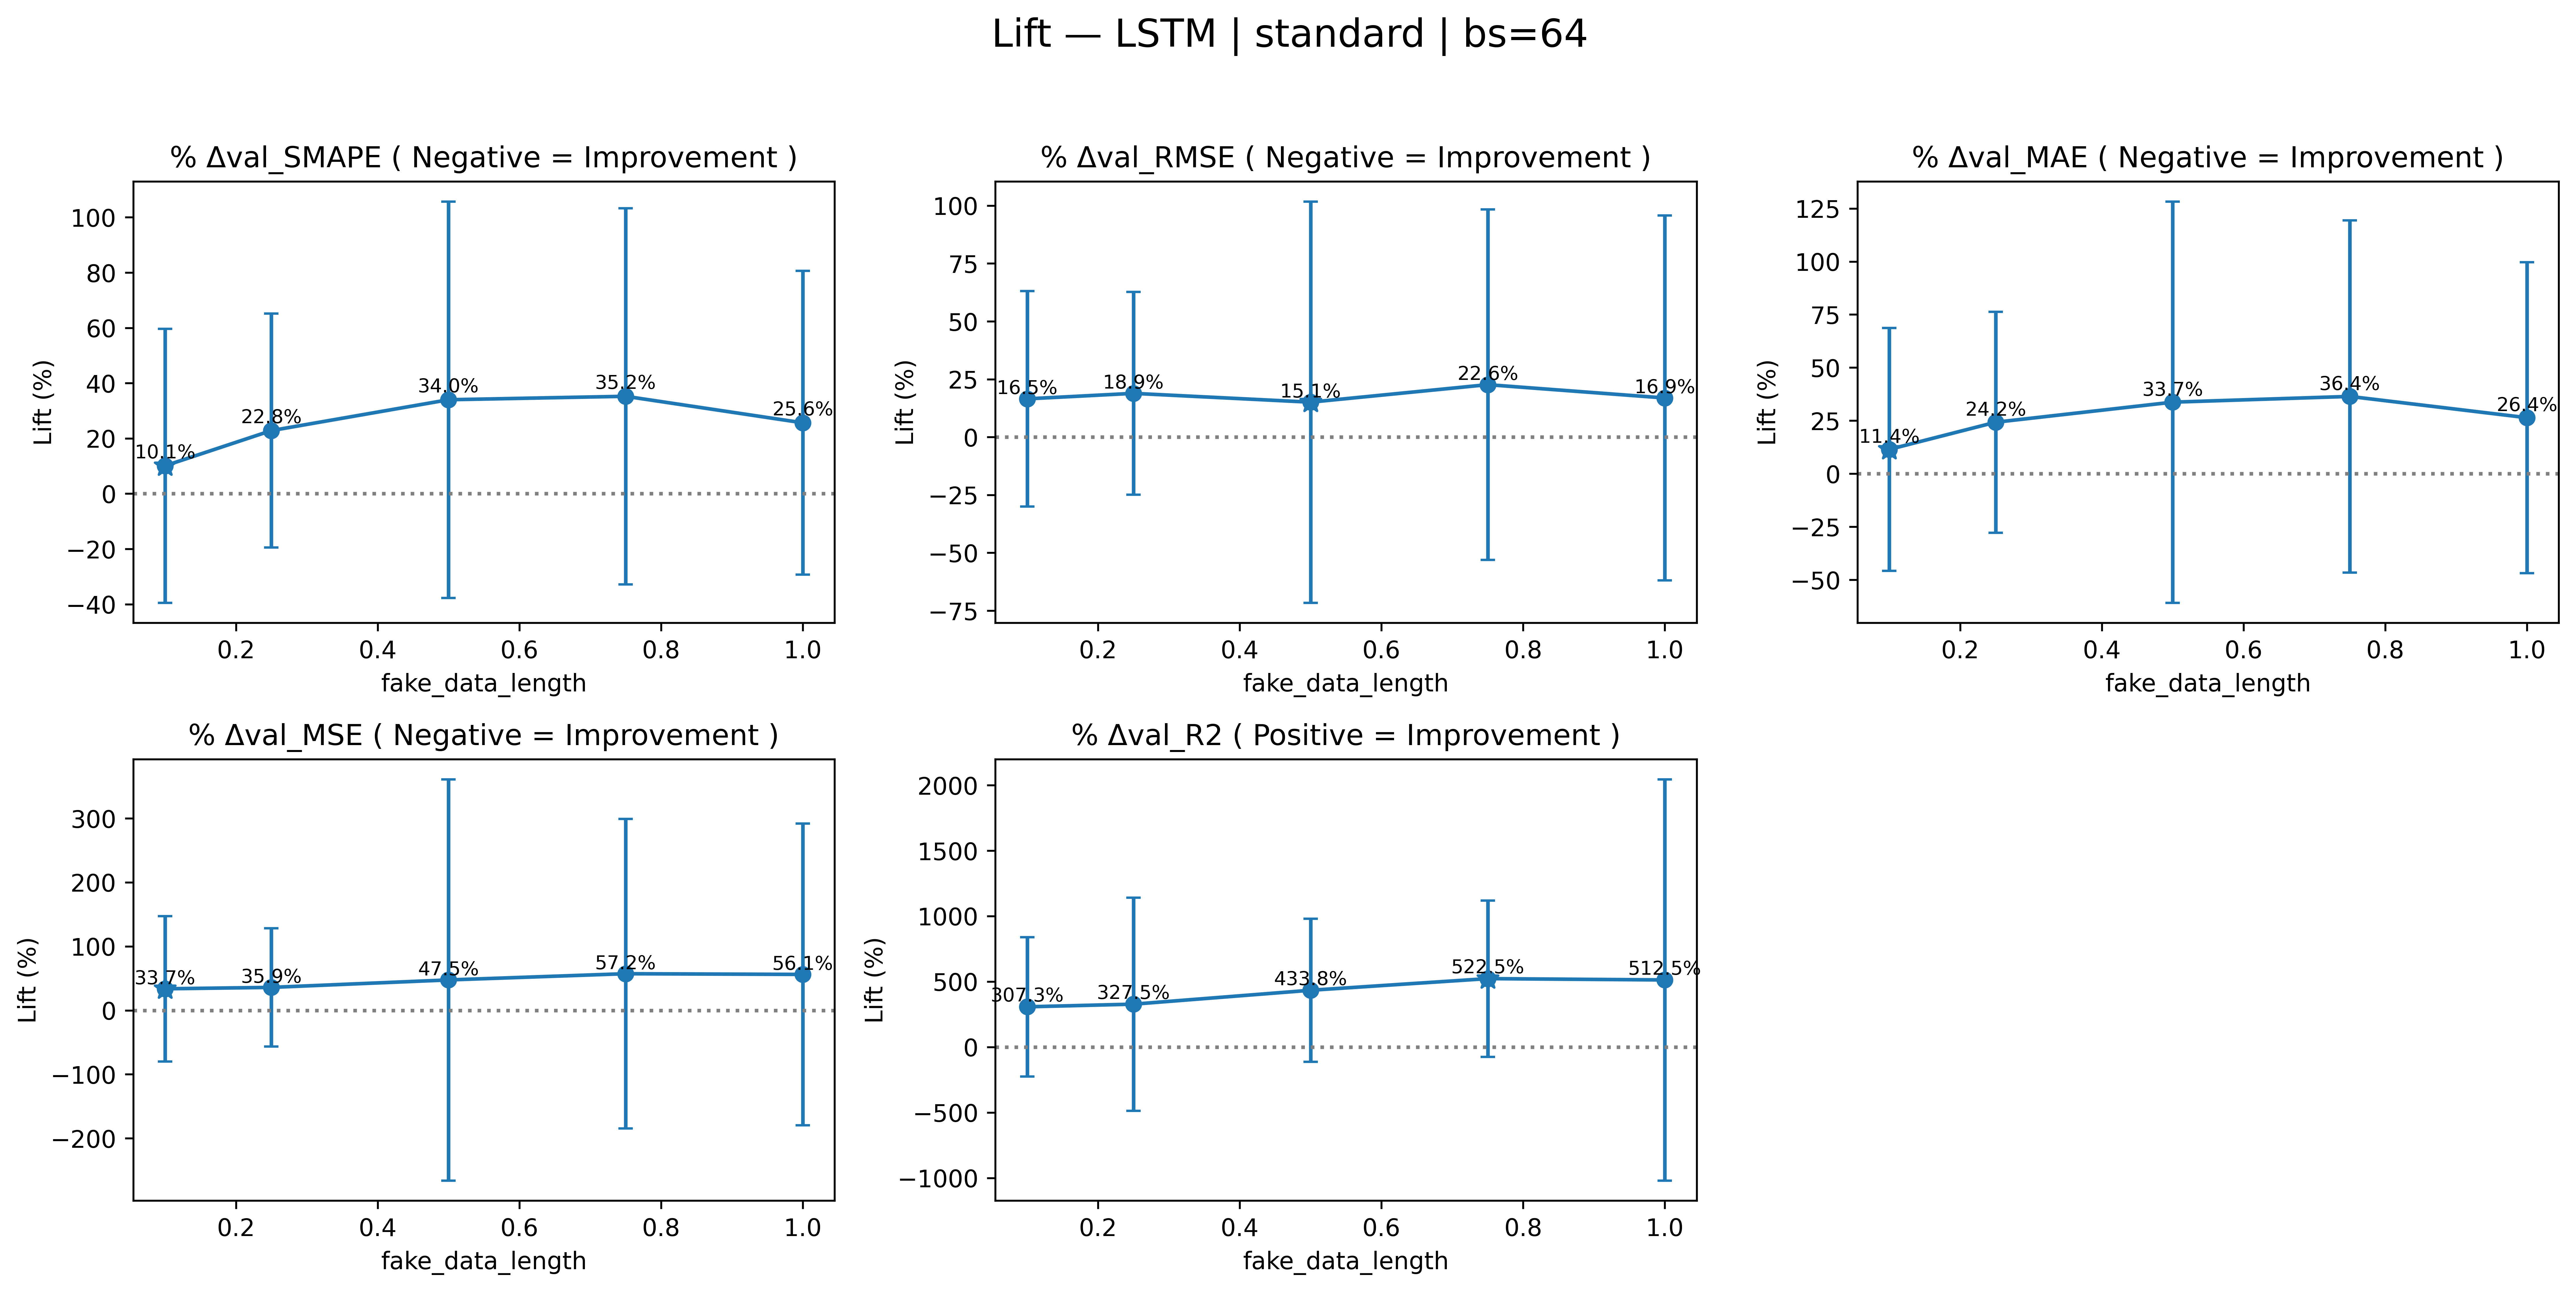

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# ---- CONFIG ----
METRICS = ['val_SMAPE', 'val_RMSE', 'val_MAE', 'val_MSE', 'val_R2']
GOOD_METRICS = {'R2'}  # metrics where higher is better (only affects titles)


# ---- 1) Build paired baseline/augmented rows (same seed) ----
def build_paired(df, metrics=METRICS):
    """
    Keep only test-stage rows, pair each augmented run with its own baseline
    for the same (model, scaler, batch, seed).
    Returns a DataFrame with both aug and base columns present.
    """
    df_all = df[df['testing_stage'] == True].copy()

    keys = ['model_name', 'scaler_name', 'batch_size', 'seed']
    base = df_all[df_all['data_augmentation'] == False][keys + metrics].copy()
    aug  = df_all[df_all['data_augmentation'] == True][keys + ['fake_data_length'] + metrics].copy()

    base = base.rename(columns={m: f'{m}_base' for m in metrics})

    paired = aug.merge(base, on=keys, how='inner', validate='many_to_one')
    # helpful labels
    paired['config_base'] = (
        paired['model_name'] + ' | ' + paired['scaler_name'] + f" | bs={paired['batch_size'].astype(str)}"
    )
    return paired

# ---- 2) Compute per-seed lift and aggregate mean/std per fake ratio ----
def compute_lift_stats_of_means(paired, metrics):
    """
    For each (model, scaler, batch, fake_data_length):
        - take mean of seeds for augmented and baseline
        - compute % lift between these means
        - compute std of per-seed lifts for error bars
    """
    out_rows = []
    group_keys = ['model_name','scaler_name','batch_size','fake_data_length']

    for metric in metrics:
        # means across seeds
        g = paired.groupby(group_keys)
        mean_aug  = g[metric].mean()
        mean_base = g[f'{metric}_base'].mean()
        lift_mean = ((mean_aug - mean_base) / mean_base * 100.0).rename('mean').reset_index()

        # std across per-seed lifts (name the column!)
        tmp = paired[group_keys].copy()
        tmp['lift_pct'] = ((paired[metric] - paired[f'{metric}_base']) / paired[f'{metric}_base'] * 100.0)
        lift_std = tmp.groupby(group_keys)['lift_pct'].std().reset_index().rename(columns={'lift_pct':'std'})

        # combine
        df_tmp = lift_mean.merge(lift_std, on=group_keys, how='left')
        df_tmp['metric'] = metric
        out_rows.append(df_tmp)

    return pd.concat(out_rows, ignore_index=True)


# ---- 3) Plot: one figure per (model, scaler, batch), subplots per metric ----
def plot_lift(stats_df, save_dir=None, dpi=300, ncols=3):
    """
    stats_df is the output of compute_lift_stats.
    Creates one figure per (model, scaler, batch), with panels for each metric.
    """
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    groups = stats_df[['model_name','scaler_name','batch_size']].drop_duplicates()

    for _, g in groups.iterrows():
        sub = stats_df[
            (stats_df['model_name']==g['model_name']) &
            (stats_df['scaler_name']==g['scaler_name']) &
            (stats_df['batch_size']==g['batch_size'])
        ].copy()

        # keep metric order consistent with METRICS
        sub['metric'] = pd.Categorical(sub['metric'], METRICS, ordered=True)
        sub = sub.sort_values(['metric','fake_data_length'])

        nmetrics = len(METRICS)
        nrows = int(np.ceil(nmetrics / ncols))
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 3.6*nrows), dpi=dpi)
        axes = np.array(axes).reshape(-1)
        for ax in axes[nmetrics:]:
            ax.axis('off')

        for i, metric in enumerate(METRICS):
            ax = axes[i]
            msub = sub[sub['metric'] == metric]
            if msub.empty:
                ax.axis('off')
                continue

            ax.errorbar(msub['fake_data_length'], msub['mean'], yerr=msub['std'],
                        marker='o', capsize=3, linestyle='-')

            # annotate values
            yr = (msub['mean'].max() - msub['mean'].min())
            y_offset = 0.05 * (yr if np.isfinite(yr) and yr != 0 else 1.0)
            for x, y in zip(msub['fake_data_length'], msub['mean']):
                ax.text(x, y + y_offset, f"{y:.1f}%", ha='center', va='bottom', fontsize=8)

            # highlight best direction
            title_dir = "Positive = Improvement" if any(t in metric.upper() for t in GOOD_METRICS) \
                        else "Negative = Improvement"
            ax.axhline(0, ls=':', c='gray')
            ax.set_title(f"% Δ{metric} ( {title_dir} )")
            ax.set_xlabel("fake_data_length")
            ax.set_ylabel("Lift (%)")

            # star the best mean point
            if any(t in metric.upper() for t in GOOD_METRICS):
                idx = msub['mean'].idxmax()
            else:
                idx = msub['mean'].idxmin()
            ax.scatter(msub.loc[idx,'fake_data_length'],
                       msub.loc[idx,'mean'], marker='*', s=80, zorder=5)

        fig.suptitle(f"Lift — {g['model_name']} | {g['scaler_name']} | bs={g['batch_size']}", y=1.03, fontsize=16)
        fig.tight_layout()

        if save_dir:
            fname = f"lift_{g['model_name']}_{g['scaler_name']}_bs{g['batch_size']}.png".replace(" ", "")
            plt.savefig(os.path.join(save_dir, fname), bbox_inches='tight', dpi=dpi)

        plt.show()

# ---- RUN ----
# df must already be your full dataframe with the columns used above
paired = build_paired(df, METRICS)
lift_stats = compute_lift_stats_of_means(paired, METRICS)
plot_lift(lift_stats, save_dir="lift_plots_means", dpi=600, ncols=3)

In [17]:
import numpy as np
import pandas as pd

def save_latex_table_from_lift_stats(
    lift_stats: pd.DataFrame,
    outfile: str = "lift_table.tex",
    good_metrics_tokens = {"R2"},        # metrics containing any of these tokens are "higher is better"
    metrics_order: list | None = None,   # e.g. ['val_SMAPE','val_RMSE','val_MAE','val_MSE','val_R2']
    fake_order: list | None = None,      # e.g. [0.10, 0.25, 0.50, 0.75, 1.00]
    fake_labeler = lambda x: f"{x:.2f}", # how to display the fake_data_length headers & Best n
    caption = r"Lift ($\Delta\%$) across all model/scaler/batch configurations. Negative = improvement.",
    label = "tab:lift"
):
    df = lift_stats.copy()

    # Determine orders if not provided
    if metrics_order is None:
        metrics_order = list(df['metric'].dropna().unique())
    if fake_order is None:
        # sort numerically but keep NaNs at end if ever present
        fake_order = sorted(df['fake_data_length'].dropna().unique())

    # Helper: escape LaTeX
    def tex_escape(s: str) -> str:
        s = str(s).replace('_', r'\_')
        rep = {'&': r'\&', '%': r'\%', '$': r'\$', '#': r'\#', '{': r'\{', '}': r'\}',
               '~': r'\textasciitilde{}', '^': r'\textasciicircum{}', '\\': r'\textbackslash{}'}
        return ''.join(rep.get(c, c) for c in s)

    # Column headers for fake lengths
    fake_headers = [fake_labeler(v) for v in fake_order]

    # Start LaTeX
    lines = []
    lines += [
        r"\begin{table*}[t]",
        r"\centering",
        rf"\caption{{{caption}}}",
        rf"\label{{{label}}}",
        r"\begin{tabular}{l l r l " + " ".join(["c"]*len(fake_headers)) + " c c}",
        r"\toprule",
        r"Model & Scaler & Batch & Metric & " + " & ".join(fake_headers) + r" & Best (\%) & Best n \\",
        r"\midrule",
    ]

    # Aggregate just in case there are multiple rows per (model,scaler,batch,metric,fake)
    grp_keys = ['model_name','scaler_name','batch_size','metric','fake_data_length']
    df_agg = (df.groupby(grp_keys)[['mean','std']]
                .mean()
                .reset_index())

    # Iterate groups in stable order: model, scaler, batch, then metrics_order
    for (mname, sname, bsz), block in df_agg.groupby(['model_name','scaler_name','batch_size'], sort=False):
        # keep metric order stable
        for metric in metrics_order:
            sub = block[block['metric'] == metric]
            if sub.empty:
                continue

            # map fake -> (mean, std)
            cell = {row['fake_data_length']: (row['mean'], row['std']) for _, row in sub.iterrows()}

            # direction
            higher_better = any(tok.upper() in str(metric).upper() for tok in good_metrics_tokens)

            # choose best (ignore NaNs)
            vals = {k: v for k, (v, _) in ((k, cell.get(k, (np.nan, np.nan))) for k in fake_order) if pd.notna(v)}
            if vals:
                best_n = max(vals, key=vals.get) if higher_better else min(vals, key=vals.get)
                best_val = vals[best_n]
                arrow = r"$\uparrow$" if higher_better else r"$\downarrow$"
            else:
                best_n, best_val, arrow = None, None, ""

            # build cells (bold the best)
            cells_tex = []
            for n in fake_order:
                mean_v, std_v = cell.get(n, (np.nan, np.nan))
                if pd.isna(mean_v):
                    txt = r"--"
                else:
                    # ensure std prints as 0.0 if NaN
                    std_v = 0.0 if pd.isna(std_v) else std_v
                    txt = f"{mean_v:.1f}$\\pm${std_v:.1f}\\%"
                if best_n is not None and n == best_n:
                    txt = r"\textbf{" + txt + "}"
                cells_tex.append(txt)

            best_pct = "--" if best_val is None else f"{best_val:.1f}\\% {arrow}"
            best_n_tex = "--" if best_n is None else tex_escape(fake_labeler(best_n))

            row = (
                f"{tex_escape(mname)} & {tex_escape(sname)} & {int(bsz)} & "
                f"{tex_escape(metric)} & " + " & ".join(cells_tex) +
                f" & {best_pct} & {best_n_tex} \\\\"
            )
            lines.append(row)

    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]

    with open(outfile, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))
    print(f"LaTeX table saved to: {outfile}")

save_latex_table_from_lift_stats(
    lift_stats,
    outfile="lift_table.tex",
    metrics_order=['val_SMAPE','val_RMSE','val_MAE','val_MSE'],
    fake_order=[0.10, 0.25, 0.50, 0.75, 1.00],
    fake_labeler=lambda x: f"{x:.2f}"  # headers shown as 0.10 ... 1.00
)

LaTeX table saved to: lift_table.tex


### heatmap of metrics vs forecasters (With Augmentation)

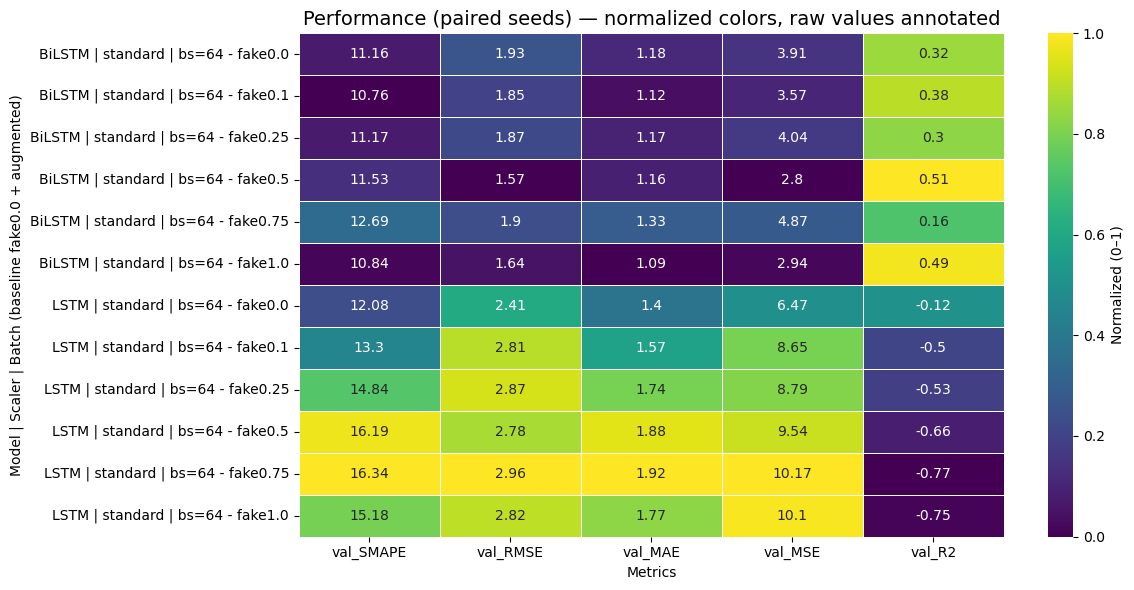

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

METRICS = ['val_SMAPE','val_RMSE','val_MAE','val_MSE','val_R2']

# 1) Build a neat label and compute means over the SAME seeds used in paired
paired['config_base_lbl'] = (
    paired['model_name'] + ' | ' + paired['scaler_name'] + ' | bs=' + paired['batch_size'].astype(str)
)
paired['config_full'] = paired['config_base_lbl'] + ' - fake' + paired['fake_data_length'].astype(str)

# 2) Means for augmented (by fake ratio) and baseline (paired-only)
aug_means = (paired
    .groupby('config_full')[METRICS]
    .mean()
)

base_means = (paired
    .groupby('config_base_lbl')[[m + '_base' for m in METRICS]]
    .mean()
    .rename(columns={m + '_base': m for m in METRICS})
)
# give baseline rows a consistent label to appear before the fakes
base_means.index = base_means.index + ' - fake0.0'

# 3) Combine and sort
heatmap_data = pd.concat([base_means, aug_means], axis=0).sort_index()

# 4) Normalize per metric for colors; annotate with raw values
normalized = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

plt.figure(figsize=(12, max(6, 0.45*len(heatmap_data))))
sns.heatmap(
    normalized,
    annot=heatmap_data.round(2),
    fmt='',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label':'Normalized (0–1)'}
)
plt.title("Performance (paired seeds) — normalized colors, raw values annotated", fontsize=14)
plt.xlabel("Metrics")
plt.ylabel("Model | Scaler | Batch (baseline fake0.0 + augmented)")
plt.tight_layout()
plt.savefig("Plots/heatmap_paired_raw.png", dpi=300)
plt.show()


### Boxplots of the forecasters

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_augmented_vs_baseline_boxplots(metric, df):
    # Create config_name: includes fake_data_length for augmented runs
    base = df['model_name'] + '-' + df['scaler_name'] + '-bs' + df['batch_size'].astype(str)
    augmented = df['data_augmentation'] & df['fake_data_length'].notna()
    df['config_name'] = base.where(~augmented, base + '-fake' + df['fake_data_length'].astype(str))

    # Add a new column: stage = 'Baseline' or 'Augmented'
    df['stage'] = df['data_augmentation'].apply(lambda x: 'Augmented' if x else 'Baseline')

    # Sort configs by baseline metric mean
    baseline_order = (
        df[df['stage'] == 'Baseline']
        .groupby('config_name')[metric]
        .mean()
        .sort_values()
        .index
    )

    # Include both baseline and augmented config names (in correct order)
    all_order = []
    for base_config in baseline_order:
        all_order.append(base_config)
        # Add all augmented variants of this config, sorted by fake_data_length
        variants = df[df['config_name'].str.startswith(base_config + '-fake')]['config_name'].unique()
        all_order.extend(sorted(variants, key=lambda x: int(x.split('fake')[-1])))

    # Plot
    plt.figure(figsize=(max(12, len(all_order) * 0.6), 6))
    ax = sns.boxplot(
        data=df[df['config_name'].isin(all_order)],
        x='config_name',
        y=metric,
        hue='stage',
        order=all_order,
        palette='Set2'
    )

    # Annotate mean values
    grouped = df.groupby(['config_name', 'stage'])[metric].mean()
    offsets = {'Baseline': -0.2, 'Augmented': 0.2}
    for i, config in enumerate(all_order):
        for stage in ['Baseline', 'Augmented']:
            if (config, stage) in grouped:
                mean_val = grouped[(config, stage)]
                ax.text(
                    i + offsets[stage],
                    mean_val + 0.01 * (df[metric].max() - df[metric].min()),
                    f"{mean_val:.2f}",
                    ha='center', va='bottom', fontsize=9,
                    color='black', fontweight='bold'
                )

    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Configuration (Baseline + Augmented)")
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison: Baseline vs Augmented")
    plt.legend(
        title="Stage",
        loc='center left',
        bbox_to_anchor=(1.01, 0.5),  # pushes it fully outside to the right
        borderaxespad=0.
    )
    plt.tight_layout(rect=[0, 0, 0.95, 1])  # leave room for legend on the right
    # plt.show()
    plt.savefig(f"Plots/boxplot_{metric}_mse_augmentation.png")


df_combined = pd.concat([df_test, df_aug], axis=0, ignore_index=True)

metrics = ['val_SMAPE', 'val_RMSE', 'val_MAE', 'val_MSE', 'val_R2']
for metric in metrics:
    plot_augmented_vs_baseline_boxplots(metric, df_combined)

ValueError: invalid literal for int() with base 10: '1.0'

# <span style="color:red; font-weight:bold">Pinball loss for DL models + XGBoost(quantile)</span>

## <span style="color:orange; font-weight:bold"> Validation stage (train vs val_1)</span>

### Import dataset

In [8]:
import numpy as np
import pandas as pd

df = pd.read_csv("wandb_pinball_updated.csv")

# # Concatenate the TFT runs
# df_TFT = pd.read_csv("TFT_pinball.csv", usecols=[c for c in df.columns if c in pd.read_csv("TFT_pinball.csv", nrows=0).columns])
# # Reindex df2 to ensure it has exactly the same columns/order as df1
# df_TFT = df_TFT.reindex(columns=df.columns)
# df = pd.concat([df, df_TFT], ignore_index=True)

# === Keep only validation stage runs ===
df_val = df[df['testing_stage'] == False].copy()

### Boxplots of the forecasters

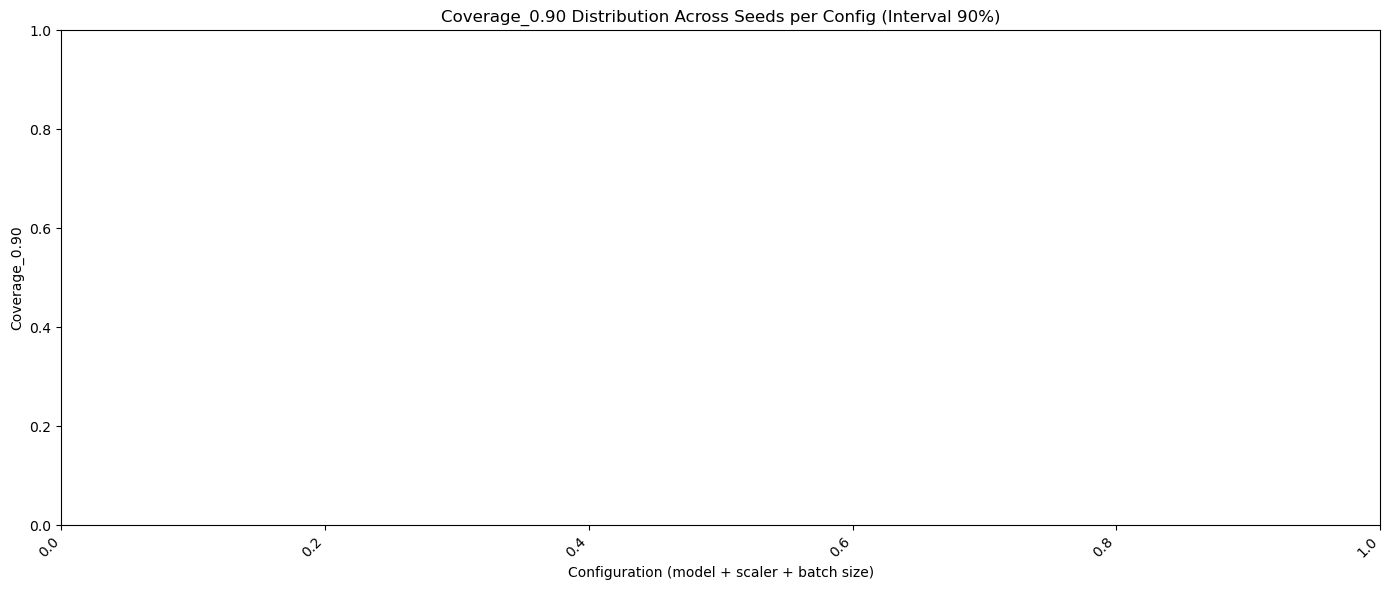

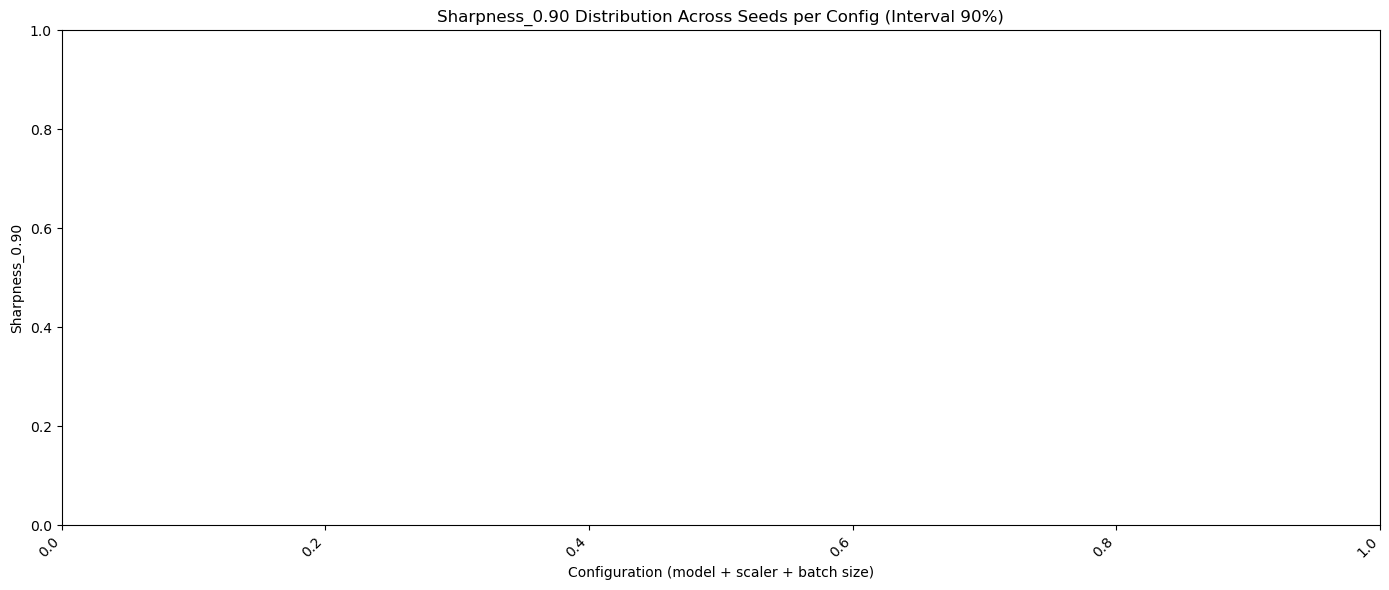

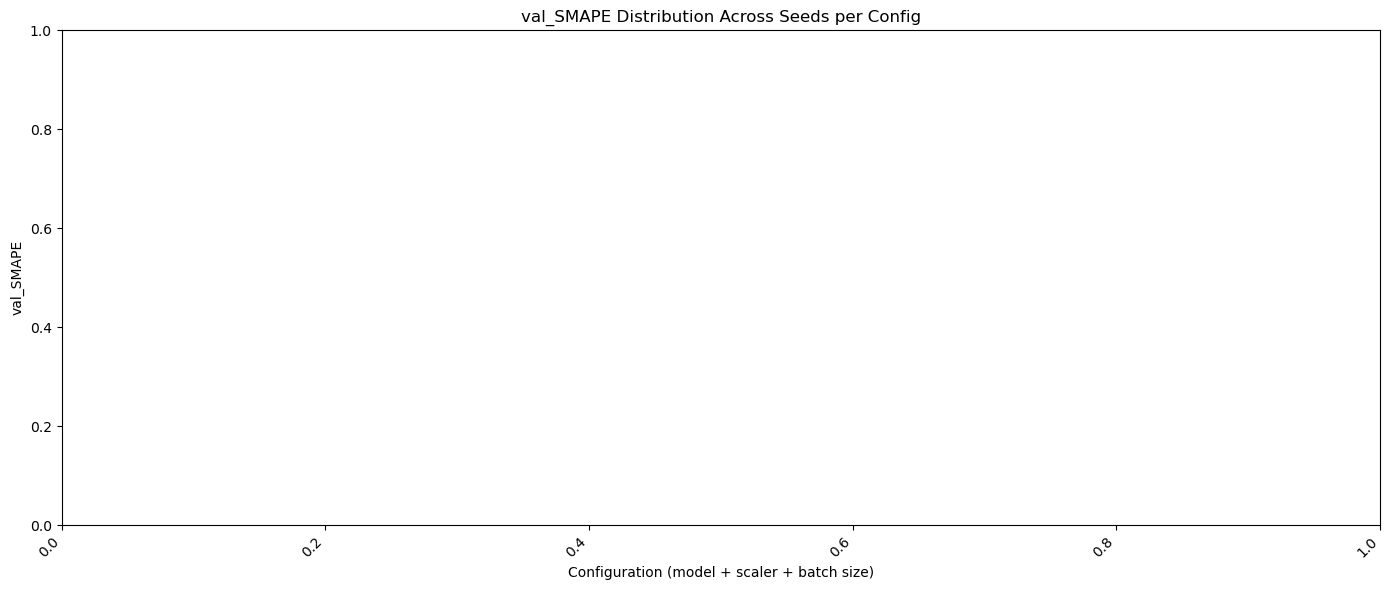

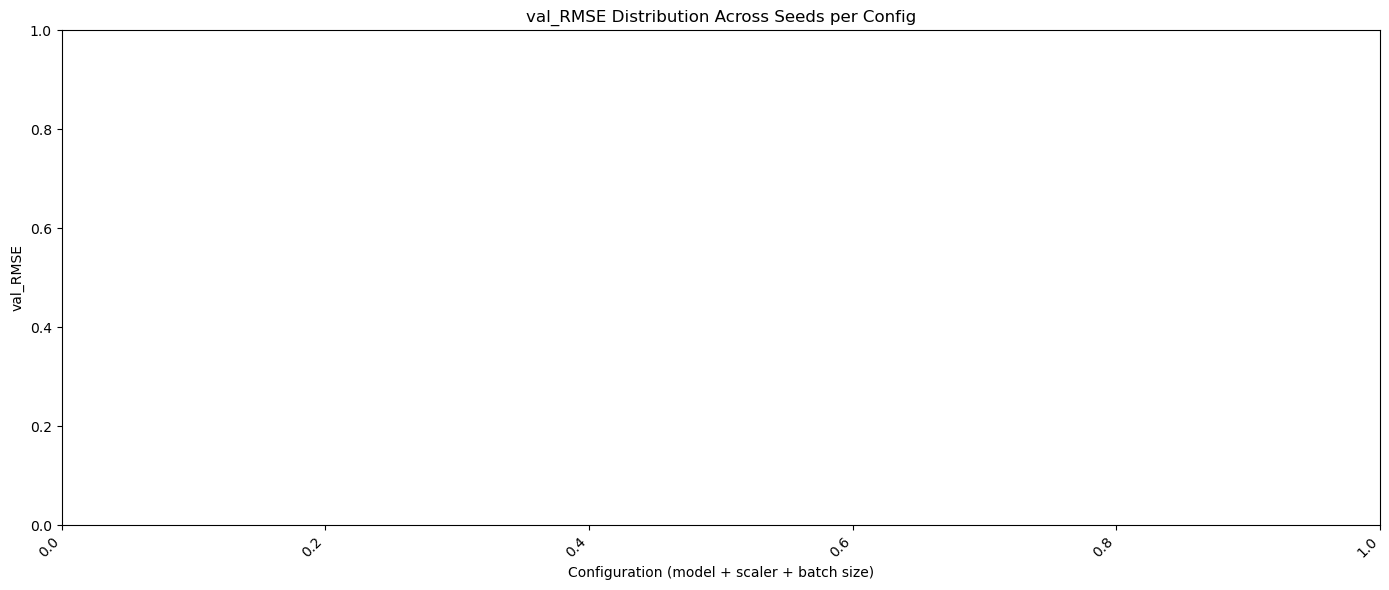

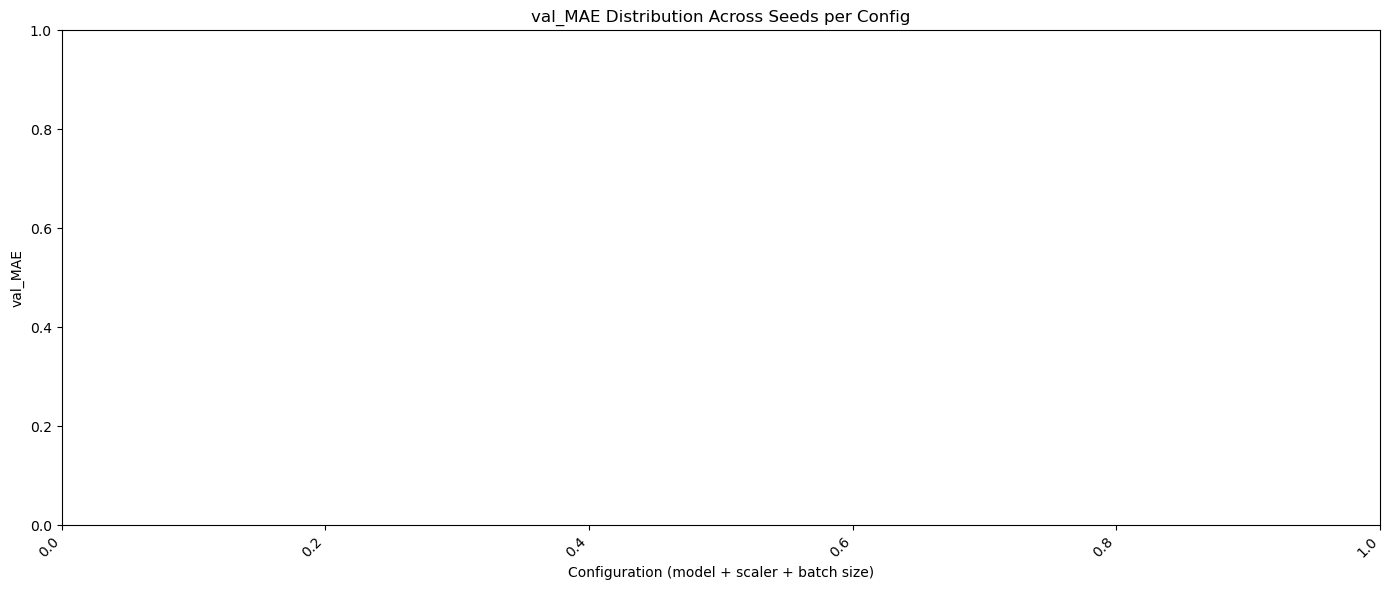

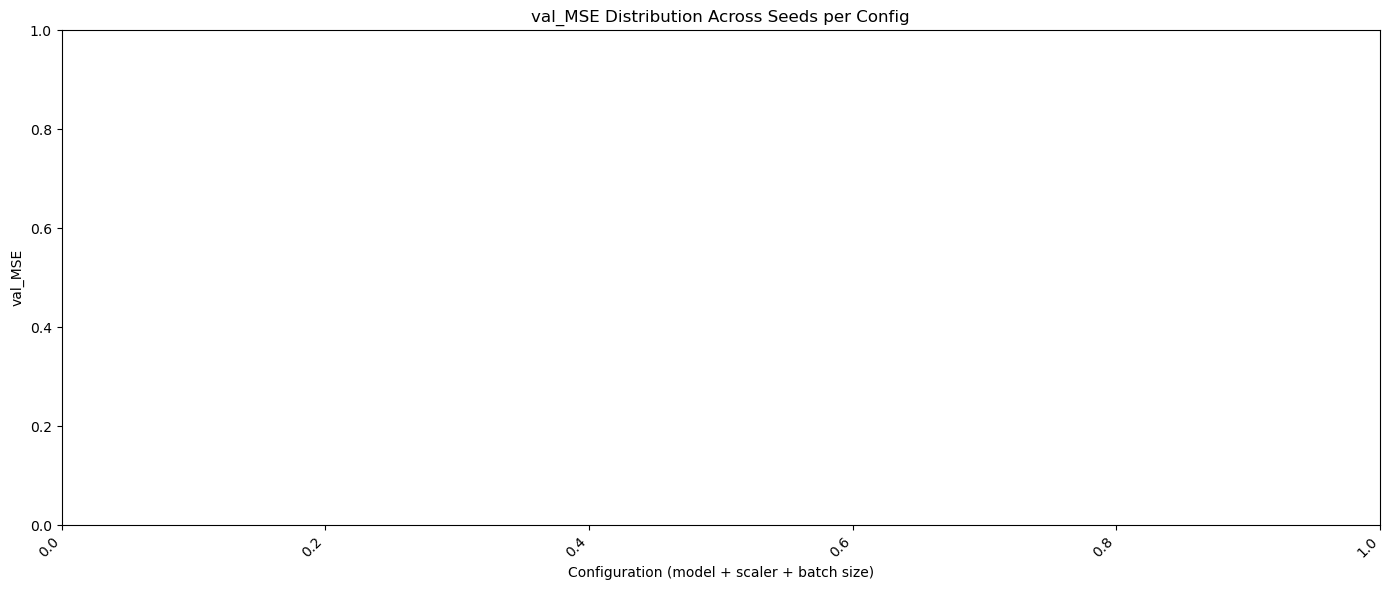

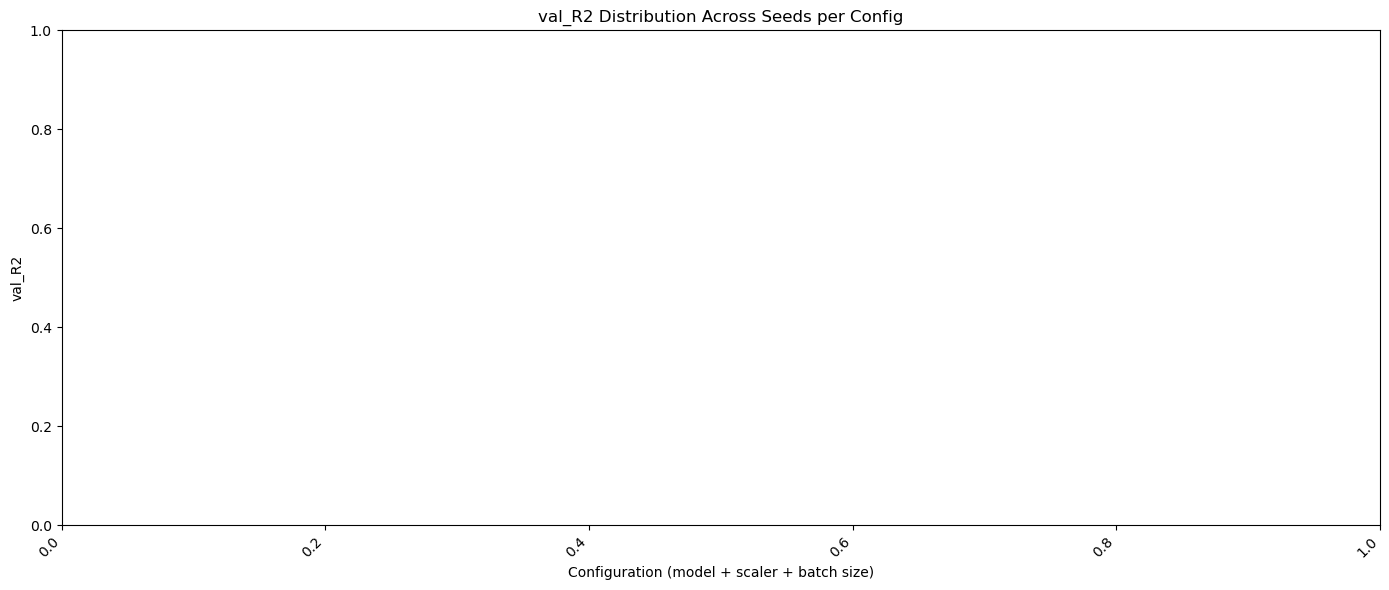

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === STEP 1: Define metric groups ===
pinball_cols = ['Pinball_0.05', 'Pinball_0.50', 'Pinball_0.95']
coverage_cols = ['Coverage_0.90']
sharpness_cols = ['Sharpness_0.90']
standard_metrics = ['val_SMAPE', 'val_RMSE', 'val_MAE', 'val_MSE', 'val_R2']

# === STEP 2: Prepare long format for pinball ===
df_pinball_long = df_val.melt(
    id_vars=['model_name', 'scaler_name', 'batch_size', 'seed', 'Name'],
    value_vars=pinball_cols,
    var_name='quantile',
    value_name='pinball_loss'
)

df_pinball_long['quantile'] = df_pinball_long['quantile'].str.extract(r'(\d+\.\d+)').astype(float)
df_pinball_long['config_name'] = (
    df_pinball_long['model_name'] + '-' +
    df_pinball_long['scaler_name'] + '-bs' +
    df_pinball_long['batch_size'].astype(str)
)

# === STEP 3: Add config_name to original df for other plots ===
df_val['config_name'] = (
    df_val['model_name'] + '-' +
    df_val['scaler_name'] + '-bs' +
    df_val['batch_size'].astype(str)
)

# === STEP 4: Plotting functions ===

def plot_pinball_loss_boxplots(df_long):
    for q in sorted(df_long['quantile'].unique()):
        sub_df = df_long[df_long['quantile'] == q]
        mean_vals = sub_df.groupby('config_name')['pinball_loss'].mean()

        if q == 0.5:
            # Special handling: group low/high pinball loss models
            threshold = 15  # Adjust as needed
            low_configs = mean_vals[mean_vals < threshold].index
            high_configs = mean_vals[mean_vals >= threshold].index

            df_low = sub_df[sub_df['config_name'].isin(low_configs)]
            df_high = sub_df[sub_df['config_name'].isin(high_configs)]

            fig, axes = plt.subplots(1, 2, figsize=(18, 6.5), gridspec_kw={'width_ratios': [1, 3]})

            # Low-loss configs
            if not df_low.empty:
                order_low = df_low.groupby('config_name')['pinball_loss'].mean().sort_values().index
                sns.boxplot(data=df_low, x='config_name', y='pinball_loss', order=order_low,
                            ax=axes[0], palette='Set2')
                axes[0].set_title("Pinball Loss Models")
                axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
                axes[0].set_xlabel("")

                # Annotations
                y_min, y_max = axes[0].get_ylim()
                offset = 0.01 * (y_max - y_min)
                for i, config in enumerate(order_low):
                    val = mean_vals[config]
                    axes[0].text(i, val + offset, f"{val:.3f}", ha='center', va='bottom',
                                fontsize=9, color='black', fontweight='bold')

            # High-loss configs
            if not df_high.empty:
                order_high = df_high.groupby('config_name')['pinball_loss'].mean().sort_values().index
                sns.boxplot(data=df_high, x='config_name', y='pinball_loss', order=order_high,
                            ax=axes[1], palette='Set2')
                axes[1].set_title("Pinball Loss Models")
                axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
                axes[1].set_xlabel("")

                y_min, y_max = axes[1].get_ylim()
                offset = 0.01 * (y_max - y_min)
                for i, config in enumerate(order_high):
                    val = mean_vals[config]
                    axes[1].text(i, val + offset, f"{val:.3f}", ha='center', va='bottom',
                                fontsize=9, color='black', fontweight='bold')

            # Final layout
            fig.suptitle(f"Pinball Loss Distribution for Quantile {q} (Grouped by Scale)", fontsize=14)
            fig.supxlabel("Configuration (model + scaler + batch size)")
            axes[0].set_ylabel("Pinball Loss")
            plt.tight_layout(rect=[0, 0.05, 1, 0.92])
            plt.savefig(f"Plots/boxplot_Pinball_{q}_pinball_validation.png")

        else:
            # Normal single boxplot for q ≠ 0.5
            order = sub_df.groupby('config_name')['pinball_loss'].mean().sort_values().index

            plt.figure(figsize=(14, 6))
            sns.boxplot(data=sub_df, x='config_name', y='pinball_loss', order=order, palette='Set2')

            y_min, y_max = sub_df['pinball_loss'].min(), sub_df['pinball_loss'].max()
            y_range = y_max - y_min
            offset = 0.02 * y_range
            for i, config in enumerate(order):
                mean_val = mean_vals[config]
                plt.text(i, mean_val + offset, f"{mean_val:.3f}",
                         ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')

            plt.xticks(rotation=45, ha='right')
            plt.xlabel("Configuration (model + scaler + batch size)")
            plt.ylabel(f"Pinball Loss (q={q})")
            plt.title(f"Pinball Loss Distribution for Quantile {q} Across Seeds")
            plt.tight_layout()
            plt.savefig(f"Plots/boxplot_Pinball_{q}_pinball_validation.png")

def plot_single_metric_boxplot(df, metric, title_suffix=""):
    order = df.groupby('config_name')[metric].mean().sort_values().index
    mean_vals = df.groupby('config_name')[metric].mean()

    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df, x='config_name', y=metric, order=order, palette='Set2')

    y_min, y_max = df[metric].min(), df[metric].max()
    y_range = y_max - y_min
    offset = 0.02 * y_range
    for i, config in enumerate(order):
        mean_val = mean_vals[config]
        plt.text(i, mean_val + offset, f"{mean_val:.3f}",
                 ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')

    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Configuration (model + scaler + batch size)")
    plt.ylabel(metric)
    plt.title(f"{metric} Distribution Across Seeds per Config{title_suffix}")
    plt.tight_layout()
    plt.savefig(f"Plots/boxplot_{metric}_pinball_validation.png")

# === STEP 5: Generate all plots ===

# 1. Pinball loss plots
plot_pinball_loss_boxplots(df_pinball_long)

# 2. Interval-based metrics
plot_single_metric_boxplot(df_val, 'Coverage_0.90', " (Interval 90%)")
plot_single_metric_boxplot(df_val, 'Sharpness_0.90', " (Interval 90%)")

# 3. Optional: Standard regression metrics for q=0.5 model
for metric in standard_metrics:
    plot_single_metric_boxplot(df_val, metric)


In [10]:
print("The best configurations (based on SMAPE) and quantile metrics are:")
print("1. Model: XGBoost, Scaler: StandardScaler")
print("2. Model: BiLSTM, Scaler: StandardScaler, Batch Size: 16")
print("3. Model: BiLSTM, Scaler: StandardScaler, Batch Size: 32")
print("4. Model: TFT, Scaler: StandardScaler, Batch Size: 16")

The best configurations (based on SMAPE) and quantile metrics are:
1. Model: XGBoost, Scaler: StandardScaler
2. Model: BiLSTM, Scaler: StandardScaler, Batch Size: 16
3. Model: BiLSTM, Scaler: StandardScaler, Batch Size: 32
4. Model: TFT, Scaler: StandardScaler, Batch Size: 16


### heatmap of metrics vs forecasters

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# === STEP 1: Create config name if needed ===
df_val['config_name'] = (
    df_val['model_name'] + '-' +
    df_val['scaler_name'] + '-bs' +
    df_val['batch_size'].astype(str)
)

# === STEP 2: Standard forecast metrics ===
standard_metrics = ['val_SMAPE', 'val_RMSE', 'val_MAE', 'val_MSE', 'val_R2']
standard_data = df_val.groupby('config_name')[standard_metrics].mean()
standard_norm = (standard_data - standard_data.min()) / (standard_data.max() - standard_data.min())

# === STEP 3: Quantile-aware metrics ===
quantile_metrics = ['Pinball_0.05', 'Pinball_0.50', 'Pinball_0.95', 'Coverage_0.90', 'Sharpness_0.90']
quantile_data = df_val.groupby('config_name')[quantile_metrics].mean()
quantile_norm = (quantile_data - quantile_data.min()) / (quantile_data.max() - quantile_data.min())

# === STEP 4: Plot heatmaps ===

def plot_heatmap(data, normalized, title):
    plt.figure(figsize=(12, len(data) * 0.6))
    sns.heatmap(
        normalized,
        annot=data.round(2),
        fmt='',
        cmap='viridis',
        linewidths=0.5,
        cbar_kws={'label': 'Normalized (0–1)'}
    )
    plt.title(title)
    plt.xlabel("Metrics")
    plt.ylabel("Forecasters (config)")
    plt.tight_layout()
    if title.startswith("Forecast"): #standard metrics
        plt.savefig(f"Plots/heatmap_stand_pinball_validation.png")
    else: # quantile metrics
        plt.savefig(f"Plots/heatmap_quant_pinball_validation.png")


# Plot standard metrics heatmap
plot_heatmap(standard_data, standard_norm, "Forecast Accuracy Heatmap (Normalized Colors, Raw Values)")

# Plot quantile-aware metrics heatmap
plot_heatmap(quantile_data, quantile_norm, "Quantile-Based Metrics Heatmap (Normalized Colors, Raw Values)")



ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1200x0 with 0 Axes>

## <span style="color:blue; font-weight:bold"> Testing stage (train+val_1 vs test)</span>

### Import dataset

In [18]:
import numpy as np
import pandas as pd

df = pd.read_csv("wandb_pinball_updated.csv")

# # Concatenate the TFT runs
# df_TFT = pd.read_csv("TFT_pinball.csv", usecols=[c for c in df.columns if c in pd.read_csv("TFT_pinball.csv", nrows=0).columns])
# # Reindex df2 to ensure it has exactly the same columns/order as df1
# df_TFT = df_TFT.reindex(columns=df.columns)
# df = pd.concat([df, df_TFT], ignore_index=True)

df_test = df[
    (df['testing_stage'] == True) &         # Only test stage runs
    (df['data_augmentation'] == False)      # Only non-augmented runs
].copy()

### Boxplots of the forecasters

/tmp/ipykernel_554901/813827221.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_554901/813827221.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_554901/813827221.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


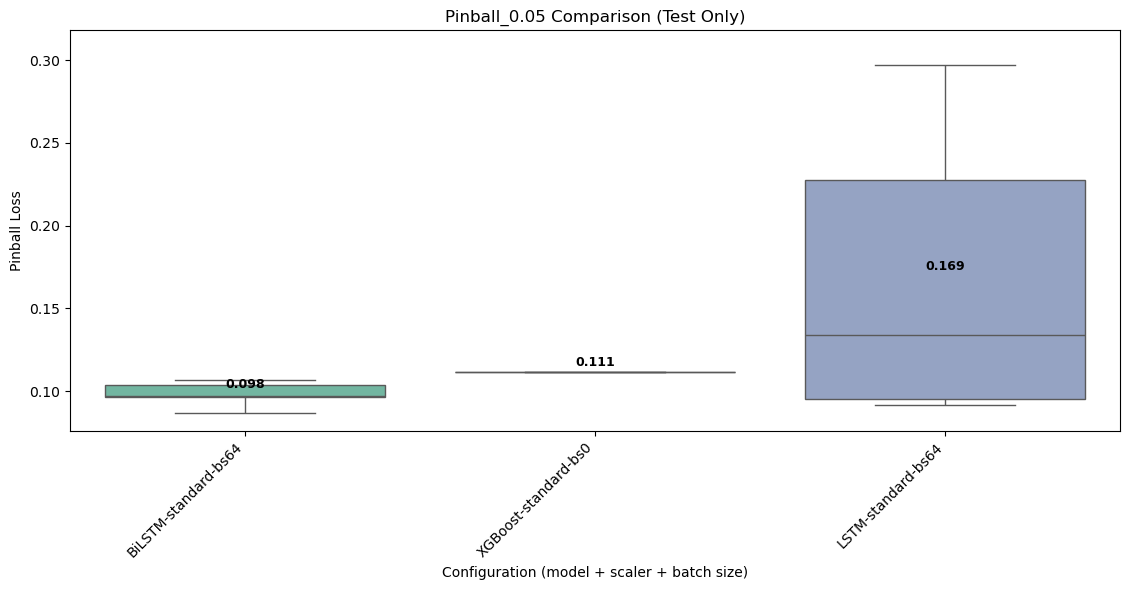

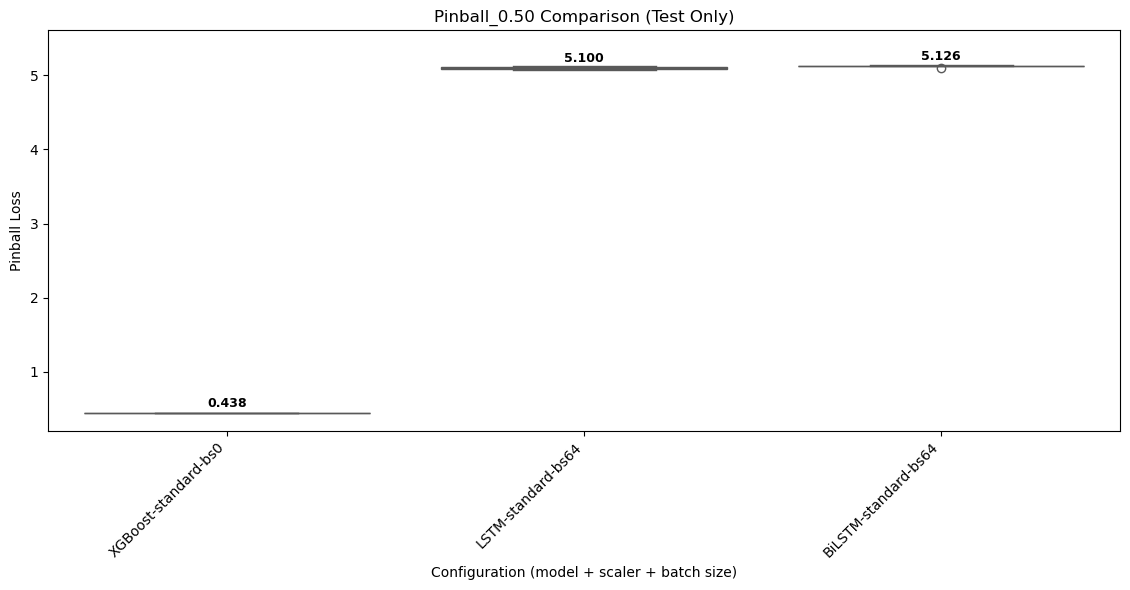

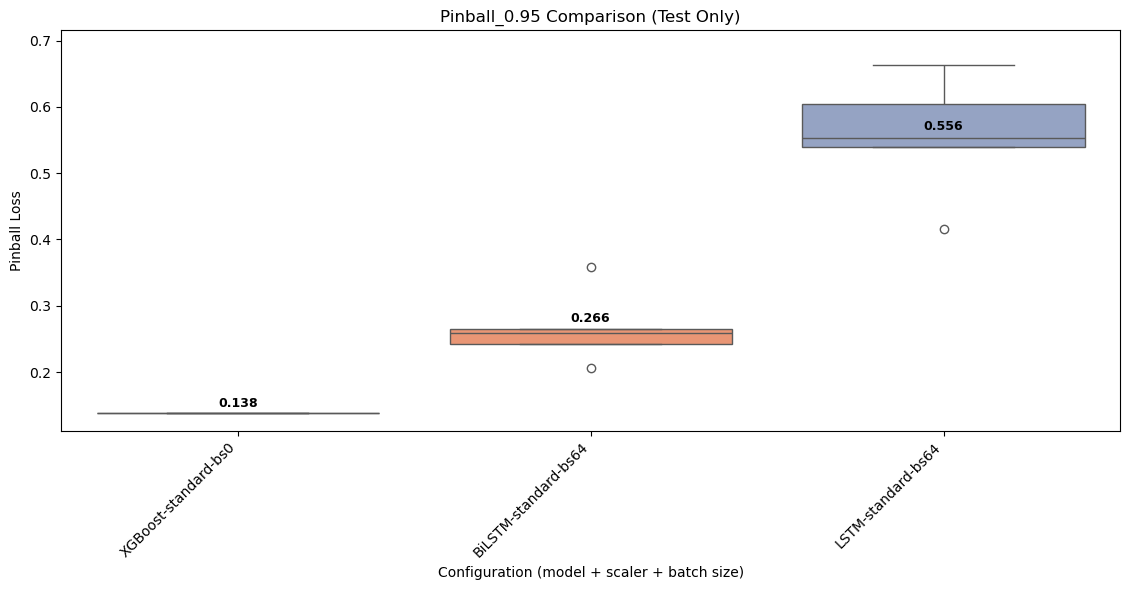

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_test_boxplots_pinball(df_test, pinball_cols=None):
    """
    Test-only boxplots for pinball losses, matching the style of your point-forecasting plots.
    - Builds `config_name` the same way
    - Orders configs by mean (Test) pinball value
    - Annotates Test means above each box
    - Saves to: Plots/boxplot_Pinball_{q}_test_only.png
    """
    if pinball_cols is None:
        pinball_cols = ['Pinball_0.05', 'Pinball_0.50', 'Pinball_0.95']

    # Copy & build config_name like point-forecasting
    df = df_test.copy()
    if 'config_name' not in df.columns:
        df['config_name'] = (
            df['model_name'] + '-' +
            df['scaler_name'] + '-bs' +
            df['batch_size'].astype(str)
        )

    # Melt to long format: one row per (config, quantile, value)
    df_long = df.melt(
        id_vars=['model_name', 'scaler_name', 'batch_size', 'seed', 'Name', 'config_name'],
        value_vars=pinball_cols,
        var_name='quantile',
        value_name='pinball_loss'
    )
    # Extract numeric quantile for cleaner filenames/titles (0.05, 0.50, 0.95)
    df_long['q'] = df_long['quantile'].str.extract(r'(\d+\.\d+)').astype(float)

    # Plot each quantile separately, matching point-forecasting style
    for q in sorted(df_long['q'].unique()):
        sub = df_long[df_long['q'] == q].copy()
        metric = f'Pinball_{q:.2f}'

        # Order configurations by mean pinball (Test only)
        order = sub.groupby('config_name')['pinball_loss'].mean().sort_values().index

        # Compute offsets for annotations/limits
        y_min = sub['pinball_loss'].min()
        y_max = sub['pinball_loss'].max()
        y_range = max(y_max - y_min, 1e-12)
        offset = 0.01 * y_range

        # Plot
        plt.figure(figsize=(12, 6))
        sns.boxplot(
            data=sub,
            x='config_name',
            y='pinball_loss',
            order=order,
            palette='Set2'
        )

        # Mean annotations
        grouped = sub.groupby('config_name')['pinball_loss'].mean()
        for i, config in enumerate(order):
            val = grouped[config]
            plt.text(
                i, val + offset, f"{val:.3f}",
                ha='center', va='bottom', fontsize=9,
                color='black', fontweight='bold'
            )

        # Labels and layout (mirrors your point-forecasting function)
        plt.xticks(rotation=45, ha='right')
        plt.xlabel("Configuration (model + scaler + batch size)")
        plt.ylabel("Pinball Loss")
        plt.title(f"{metric} Comparison (Test Only)")
        plt.ylim(y_min - 0.05 * y_range, y_max + 0.1 * y_range)
        plt.tight_layout(rect=[0, 0, 0.95, 1])

        # Save
        plt.savefig(f"Plots/boxplot_{metric}_test_only.png")
        # plt.show()

# --- Run for all pinball quantiles (Test only) ---
plot_test_boxplots_pinball(df_test, pinball_cols=['Pinball_0.05', 'Pinball_0.50', 'Pinball_0.95'])


### heatmap of metrics vs forecasters

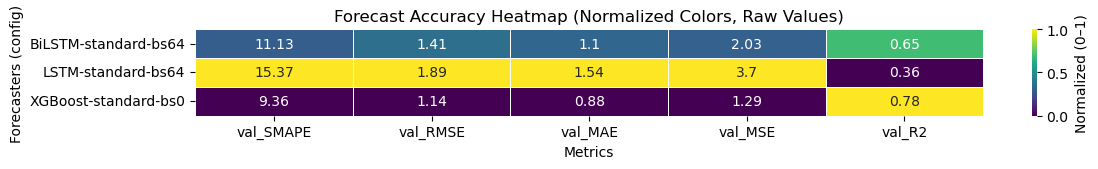

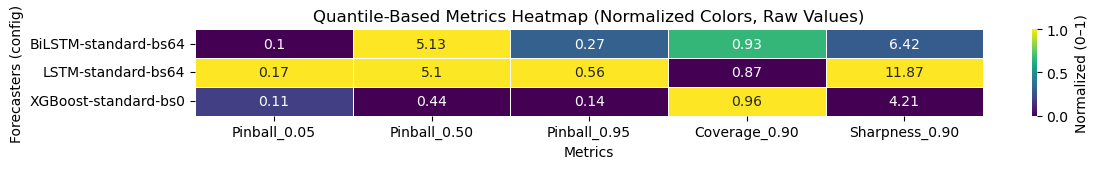

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# === STEP 1: Create config name if needed ===
df_test['config_name'] = (
    df_test['model_name'] + '-' +
    df_test['scaler_name'] + '-bs' +
    df_test['batch_size'].astype(str)
)
    
# === STEP 2: Standard forecast metrics ===
standard_metrics = ['val_SMAPE', 'val_RMSE', 'val_MAE', 'val_MSE', 'val_R2']
standard_data = df_test.groupby('config_name')[standard_metrics].mean()
standard_norm = (standard_data - standard_data.min()) / (standard_data.max() - standard_data.min())

# === STEP 3: Quantile-aware metrics ===
quantile_metrics = ['Pinball_0.05', 'Pinball_0.50', 'Pinball_0.95', 'Coverage_0.90', 'Sharpness_0.90']
quantile_data = df_test.groupby('config_name')[quantile_metrics].mean()
quantile_norm = (quantile_data - quantile_data.min()) / (quantile_data.max() - quantile_data.min())

# === STEP 4: Plot heatmaps ===

def plot_heatmap(data, normalized, title):
    plt.figure(figsize=(12, len(data) * 0.6))
    sns.heatmap(
        normalized,
        annot=data.round(2),
        fmt='',
        cmap='viridis',
        linewidths=0.5,
        cbar_kws={'label': 'Normalized (0–1)'}
    )
    plt.title(title)
    plt.xlabel("Metrics")
    plt.ylabel("Forecasters (config)")
    plt.tight_layout()
    if title.startswith("Forecast"): #standard metrics
        plt.savefig(f"Plots/heatmap_stand_pinball_testing.png")
    else: # quantile metrics
        plt.savefig(f"Plots/heatmap_quant_pinball_testing.png")

# Plot standard metrics heatmap
plot_heatmap(standard_data, standard_norm, "Forecast Accuracy Heatmap (Normalized Colors, Raw Values)")

# Plot quantile-aware metrics heatmap
plot_heatmap(quantile_data, quantile_norm, "Quantile-Based Metrics Heatmap (Normalized Colors, Raw Values)")



## <span style="color:green; font-weight:bold"> Data Augmentation stage</span>

### Import dataset

In [21]:
import pandas as pd
df = pd.read_csv("wandb_pinball_updated.csv")

# # Concatenate the TFT runs
# df_TFT = pd.read_csv("TFT_pinball.csv", usecols=[c for c in df.columns if c in pd.read_csv("TFT_pinball.csv", nrows=0).columns])
# # Reindex df2 to ensure it has exactly the same columns/order as df1
# df_TFT = df_TFT.reindex(columns=df.columns)
# df = pd.concat([df, df_TFT], ignore_index=True)


# df_aug = df[
#     (df['testing_stage'] == True) &         # Only test stage runs
#     (df['data_augmentation'] == True)       # Only augmented runs
# ].copy()

### Compute Lift metric plots

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Config
# =========================
METRICS = ['val_SMAPE', 'val_RMSE', 'val_MAE', 'val_MSE', 'val_R2']
# "Good" metrics: higher is better
GOOD_METRICS  = {"R2"}   # checked as substring, case-insensitive (e.g., "val_R2")

# =========================
# Helpers
# =========================
def _fmt_len(x):
    # pretty column headers like 0.1, 0.25, 0.5, 0.75, 1, 2, etc.
    # strips trailing zeros while keeping a dot if needed
    s = f"{float(x):g}"
    return s

def _is_good_metric(metric_name: str) -> bool:
    name = metric_name.upper()
    return any(tok in name for tok in GOOD_METRICS)

def _safe_y_offset(series: pd.Series, frac: float = 0.05) -> float:
    if series.empty or not np.isfinite(series).all():
        return 0.5
    rng = series.max() - series.min()
    return frac * (rng if (np.isfinite(rng) and rng != 0) else 1.0)

# =========================
# Pairing and lift stats
# =========================
def build_paired(df: pd.DataFrame, metrics):
    """
    Keep only test-stage rows; pair each augmented run with its own baseline
    for the same (model, scaler, batch, seed).
    Returns a DataFrame with both aug and base columns present.
    """
    df_all = df[df['testing_stage'] == True].copy()

    keys = ['model_name', 'scaler_name', 'batch_size', 'seed']
    base = df_all[df_all['data_augmentation'] == False][keys + metrics].copy()
    aug  = df_all[df_all['data_augmentation'] == True][keys + ['fake_data_length'] + metrics].copy()

    base = base.rename(columns={m: f'{m}_base' for m in metrics})
    paired = aug.merge(base, on=keys, how='inner', validate='many_to_one')

    paired['config_base'] = (
        paired['model_name'] + ' | ' + paired['scaler_name'] + f" | bs={paired['batch_size'].astype(str)}"
    )
    return paired

def compute_lift_stats_of_means(paired: pd.DataFrame, metrics):
    """
    For each (model, scaler, batch, fake_data_length):
      - take mean of seeds for augmented and baseline
      - compute % lift between these means
      - compute std of per-seed lifts for error bars
    Returns long DataFrame with columns:
      [model_name, scaler_name, batch_size, fake_data_length, metric, mean, std]
    """
    out_rows = []
    group_keys = ['model_name','scaler_name','batch_size','fake_data_length']

    for metric in metrics:
        g = paired.groupby(group_keys)
        mean_aug  = g[metric].mean()
        mean_base = g[f'{metric}_base'].mean()
        lift_mean = ((mean_aug - mean_base) / mean_base * 100.0).rename('mean').reset_index()

        tmp = paired[group_keys].copy()
        tmp['lift_pct'] = ((paired[metric] - paired[f'{metric}_base']) / paired[f'{metric}_base'] * 100.0)
        lift_std = tmp.groupby(group_keys)['lift_pct'].std().reset_index().rename(columns={'lift_pct':'std'})

        df_tmp = lift_mean.merge(lift_std, on=group_keys, how='left')
        df_tmp['metric'] = metric
        out_rows.append(df_tmp)

    stats_df = pd.concat(out_rows, ignore_index=True)
    # Consistent metric ordering for later plotting
    stats_df['metric'] = pd.Categorical(stats_df['metric'], metrics, ordered=True)
    return stats_df

# =========================
# Plotting (per group, subplots per metric)
# =========================
def plot_lift(stats_df: pd.DataFrame, metrics, save_dir=None, dpi=300, ncols=3):
    """
    Creates one figure per (model, scaler, batch) with panels for each metric.
    Uses mean±std error bars over fake_data_length and stars the best point
    (min for error metrics, max for "good" metrics like R2).
    """
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    groups = stats_df[['model_name','scaler_name','batch_size']].drop_duplicates()

    for _, g in groups.iterrows():
        sub = stats_df[
            (stats_df['model_name']==g['model_name']) &
            (stats_df['scaler_name']==g['scaler_name']) &
            (stats_df['batch_size']==g['batch_size'])
        ].copy().sort_values(['metric','fake_data_length'])

        nmetrics = len(metrics)
        nrows = int(np.ceil(nmetrics / ncols))
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 3.6*nrows), dpi=dpi)
        axes = np.array(axes).reshape(-1)

        # Turn off extras
        for ax in axes[nmetrics:]:
            ax.axis('off')

        for i, metric in enumerate(metrics):
            ax = axes[i]
            msub = sub[sub['metric'] == metric]
            if msub.empty:
                ax.axis('off')
                continue

            ax.errorbar(
                msub['fake_data_length'],
                msub['mean'],
                yerr=msub['std'],
                marker='o',
                capsize=3,
                linestyle='-'
            )

            # annotate means
            y_off = _safe_y_offset(msub['mean'], frac=0.05)
            for x, y in zip(msub['fake_data_length'], msub['mean']):
                ax.text(x, y + y_off, f"{y:.1f}%", ha='center', va='bottom', fontsize=8)

            # best direction
            is_good = _is_good_metric(metric)
            ax.axhline(0, ls=':', c='gray')
            dir_text = "Positive = Improvement" if is_good else "Negative = Improvement"
            ax.set_title(f"% Δ{metric} ({dir_text})")
            ax.set_xlabel("fake_data_length")
            ax.set_ylabel("Lift (%)")

            # star best
            if not msub.empty and msub['mean'].notna().any():
                best_idx = msub['mean'].idxmax() if is_good else msub['mean'].idxmin()
                ax.scatter(
                    msub.loc[best_idx, 'fake_data_length'],
                    msub.loc[best_idx, 'mean'],
                    marker='*', s=80, zorder=5
                )

        fig.suptitle(f"Lift — {g['model_name']} | {g['scaler_name']} | bs={g['batch_size']}", y=1.03, fontsize=16)
        fig.tight_layout()

        if save_dir:
            fname = f"lift_{g['model_name']}_{g['scaler_name']}_bs{g['batch_size']}.png".replace(" ", "")
            plt.savefig(os.path.join(save_dir, fname), bbox_inches='tight', dpi=dpi)

        plt.show()

# # =========================
# # LaTeX table builders
# # =========================
# def compute_lift_stats_for_group(df_all, model, scaler, batch_size, metrics):
#     """
#     Returns dict(metric -> stats_df with columns: fake_data_length, mean, std)
#     Computed as mean±std of per-seed lifts.
#     """
#     out = {}
#     df_filtered = df_all[
#         (df_all['model_name'] == model) &
#         (df_all['scaler_name'] == scaler) &
#         (df_all['batch_size'] == batch_size) &
#         (df_all['testing_stage'] == True)
#     ].copy()

#     base = df_filtered[df_filtered['data_augmentation'] == False].set_index(['seed'])
#     aug  = df_filtered[df_filtered['data_augmentation'] == True].set_index(['seed'])

#     # Join baseline metrics per-seed
#     aug = aug.join(base[[m for m in metrics]], rsuffix='_no_aug', how='left').reset_index()

#     for metric in metrics:
#         lift = ((aug[metric] - aug[f"{metric}_no_aug"]) / aug[f"{metric}_no_aug"]) * 100
#         tmp = aug[['fake_data_length']].copy()
#         tmp['lift'] = lift
#         stats = tmp.groupby('fake_data_length')['lift'].agg(['mean', 'std']).reset_index()
#         out[metric] = stats
#     return out

# def format_mean_std(mean, std, decimals=1):
#     if pd.isna(mean):
#         return ""
#     if pd.isna(std) or std == 0:
#         return f"{mean:.{decimals}f}\\%"
#     return f"{mean:.{decimals}f}±{std:.{decimals}f}\\%"

# def build_lift_table_for_group(df_all, model, scaler, batch_size, metrics, decimals=1):
#     """
#     Returns (wide_df, best_rows_df) where wide_df has one row per metric and columns
#     per fake_data_length (+ Best columns).  IMPORTANT: keeps fake_data_length as float.
#     """
#     stats_dict = compute_lift_stats_for_group(df_all, model, scaler, batch_size, metrics)
#     # union of all lengths across metrics, kept as floats and sorted numerically
#     all_lengths = sorted({
#         float(v) for s in stats_dict.values() if not s.empty for v in s['fake_data_length'].tolist()
#     })

#     rows, best_rows = [], []
#     for metric in metrics:
#         stats = stats_dict[metric]
#         # map exact float length -> (mean, std)
#         m = {float(r['fake_data_length']): (r['mean'], r['std']) for _, r in stats.iterrows()}

#         is_good = _is_good_metric(metric)
#         if not stats.empty:
#             best_idx = stats['mean'].idxmax() if is_good else stats['mean'].idxmin()
#             best_len = float(stats.loc[best_idx, 'fake_data_length'])
#             best_mean = float(stats.loc[best_idx, 'mean'])
#         else:
#             best_len, best_mean = (np.nan, np.nan)

#         row = {"Metric": metric}
#         for L in all_lengths:
#             mean, std = m.get(L, (np.nan, np.nan))
#             row[_fmt_len(L)] = format_mean_std(mean, std, decimals)

#         direction = "↑" if is_good else "↓"
#         row["Best (lift)"] = f"{best_mean:.{decimals}f}\\% {direction}" if pd.notna(best_mean) else ""
#         row["Best n"] = _fmt_len(best_len) if pd.notna(best_len) else ""
#         rows.append(row)

#         best_rows.append({
#             "Metric": metric,
#             "Best_n": best_len,
#             "Best_lift_mean_%": best_mean
#         })

#     wide_df = pd.DataFrame(rows)
#     if all_lengths:
#         wide_df = wide_df[["Metric"] + [_fmt_len(L) for L in all_lengths] + ["Best (lift)", "Best n"]]

#     best_rows_df = pd.DataFrame(best_rows)
#     return wide_df, best_rows_df

# def tables_to_latex(
#     df_all,
#     df_aug,  # only used to enumerate groups
#     metrics,
#     save_dir="latex_tables",
#     decimals=1,
#     combine_all=False,
#     table_caption_tpl=(
#         "Lift (Δ\\%) vs. baseline across synthetic lengths for {model} | {scaler} | bs={bs}. "
#         "Negative is better for error metrics; positive is better for R²."
#     ),
#     table_label_tpl="tab:lift_{model}_{scaler}_bs{bs}",
#     use_booktabs=True
# ):
#     os.makedirs(save_dir, exist_ok=True)
#     grouped = df_aug[['model_name', 'scaler_name', 'batch_size']].drop_duplicates()

#     combined_tables = []

#     for _, row in grouped.iterrows():
#         model = row['model_name']
#         scaler = row['scaler_name']
#         bs = row['batch_size']

#         table_df, _ = build_lift_table_for_group(df_all, model, scaler, bs, metrics, decimals=decimals)

#         table_tex = table_df.to_latex(
#             index=False,
#             escape=False,   # <<<<<< key change
#             column_format="l" + "c"*(table_df.shape[1]-1),
#             longtable=False,
#             bold_rows=False,
#             na_rep="",
#             caption=table_caption_tpl.format(model=model, scaler=scaler, bs=bs),
#             label=table_label_tpl.format(model=str(model).replace(' ',''), scaler=str(scaler).replace(' ',''), bs=bs),
#             multicolumn=True,
#             multicolumn_format='c',
#             buf=None
#         )
#         if use_booktabs:
#             table_tex = table_tex.replace("\\toprule", "\\toprule").replace("\\midrule", "\\midrule").replace("\\bottomrule", "\\bottomrule")

#         fname = os.path.join(save_dir, f"lift_{model}_{scaler}_bs{bs}.tex").replace(" ", "")
#         with open(fname, "w", encoding="utf-8") as f:
#             f.write(table_tex)

#         if combine_all:
#             tmp = table_df.copy()
#             tmp.insert(0, "Model", model)
#             tmp.insert(1, "Scaler", scaler)
#             tmp.insert(2, "Batch", bs)
#             combined_tables.append(tmp)

#     if combine_all and combined_tables:
#         big = pd.concat(combined_tables, ignore_index=True)
#         big_tex = big.to_latex(
#             index=False,
#             escape=True,
#             column_format="l"*3 + "c"*(big.shape[1]-3),
#             caption="Lift (Δ\\%) across all model/scaler/batch configurations.",
#             label="tab:lift_all",
#         )
#         with open(os.path.join(save_dir, "lift_all_pinball.tex"), "w", encoding="utf-8") as f:
#             f.write(big_tex)
#     return True

# =========================
# High-level convenience wrapper (build -> stats -> plot)
# =========================
def run_augmentation_lift_pipeline(df, metrics, save_plot_dir="lift_plots", plot_dpi=600, ncols=3):
    paired = build_paired(df, metrics)
    stats  = compute_lift_stats_of_means(paired, metrics)
    plot_lift(stats, metrics=metrics, save_dir=save_plot_dir, dpi=plot_dpi, ncols=ncols)
    return stats

# =========================
# Usage
# =========================
# Include all metrics you care about (errors + R2 + pinball + interval metrics)
metrics = [
    'val_RMSE', 'val_SMAPE', 'val_MAE', 'val_MSE', 'val_R2',
    'Pinball_0.05', 'Pinball_0.50', 'Pinball_0.95',
    'Sharpness_0.90'
]

# 1) Plots (per (model, scaler, bs), subplots per metric)
stats_df = run_augmentation_lift_pipeline(df, metrics, save_plot_dir="lift_plots", plot_dpi=600, ncols=3)

# # 2) Tables (LaTeX)
# tables_to_latex(
#     df_all=df,     # full dataframe
#     df_aug=df[df['data_augmentation'] == True],  # to enumerate groups
#     metrics=metrics,
#     save_dir="latex_tables",
#     decimals=1,
#     combine_all=True
# )

,model_name,scaler_name,batch_size,fake_data_length,mean,std,metric
0,BiLSTM,standard,64,0.10,-5.325754,10.724959,val_RMSE
1,BiLSTM,standard,64,0.25,-5.316064,25.252605,val_RMSE
2,BiLSTM,standard,64,0.50,-3.475638,20.833625,val_RMSE
3,BiLSTM,standard,64,0.75,7.356620,53.114656,val_RMSE
4,BiLSTM,standard,64,1.00,-7.870887,20.761478,val_RMSE
...,...,...,...,...,...,...,...
85,LSTM,standard,64,0.10,-6.743301,19.994571,Sharpness_0.90
86,LSTM,standard,64,0.25,-7.358482,16.372749,Sharpness_0.90
87,LSTM,standard,64,0.50,5.212517,11.145585,Sharpness_0.90
88,LSTM,standard,64,0.75,-15.191437,22.824059,Sharpness_0.90


In [24]:
import numpy as np
import pandas as pd

def save_latex_table_from_lift_stats(
    lift_stats: pd.DataFrame,
    outfile: str = "lift_table.tex",
    good_metrics_tokens = {"R2"},        # metrics containing any of these tokens are "higher is better"
    metrics_order: list | None = None,   # e.g. ['val_SMAPE','val_RMSE','val_MAE','val_MSE','val_R2']
    fake_order: list | None = None,      # e.g. [0.10, 0.25, 0.50, 0.75, 1.00]
    fake_labeler = lambda x: f"{x:.2f}", # how to display the fake_data_length headers & Best n
    caption = r"Lift ($\Delta\%$) across all model/scaler/batch configurations. Negative = improvement.",
    label = "tab:lift"
):
    df = lift_stats.copy()

    # Determine orders if not provided
    if metrics_order is None:
        metrics_order = list(df['metric'].dropna().unique())
    if fake_order is None:
        # sort numerically but keep NaNs at end if ever present
        fake_order = sorted(df['fake_data_length'].dropna().unique())

    # Helper: escape LaTeX
    def tex_escape(s: str) -> str:
        s = str(s).replace('_', r'\_')
        rep = {'&': r'\&', '%': r'\%', '$': r'\$', '#': r'\#', '{': r'\{', '}': r'\}',
               '~': r'\textasciitilde{}', '^': r'\textasciicircum{}', '\\': r'\textbackslash{}'}
        return ''.join(rep.get(c, c) for c in s)

    # Column headers for fake lengths
    fake_headers = [fake_labeler(v) for v in fake_order]

    # Start LaTeX
    lines = []
    lines += [
        r"\begin{table*}[t]",
        r"\centering",
        rf"\caption{{{caption}}}",
        rf"\label{{{label}}}",
        r"\begin{tabular}{l l r l " + " ".join(["c"]*len(fake_headers)) + " c c}",
        r"\toprule",
        r"Model & Scaler & Batch & Metric & " + " & ".join(fake_headers) + r" & Best (\%) & Best n \\",
        r"\midrule",
    ]

    # Aggregate just in case there are multiple rows per (model,scaler,batch,metric,fake)
    grp_keys = ['model_name','scaler_name','batch_size','metric','fake_data_length']
    df_agg = (df.groupby(grp_keys)[['mean','std']]
                .mean()
                .reset_index())

    # Iterate groups in stable order: model, scaler, batch, then metrics_order
    for (mname, sname, bsz), block in df_agg.groupby(['model_name','scaler_name','batch_size'], sort=False):
        # keep metric order stable
        for metric in metrics_order:
            sub = block[block['metric'] == metric]
            if sub.empty:
                continue

            # map fake -> (mean, std)
            cell = {row['fake_data_length']: (row['mean'], row['std']) for _, row in sub.iterrows()}

            # direction
            higher_better = any(tok.upper() in str(metric).upper() for tok in good_metrics_tokens)

            # choose best (ignore NaNs)
            vals = {k: v for k, (v, _) in ((k, cell.get(k, (np.nan, np.nan))) for k in fake_order) if pd.notna(v)}
            if vals:
                best_n = max(vals, key=vals.get) if higher_better else min(vals, key=vals.get)
                best_val = vals[best_n]
                arrow = r"$\uparrow$" if higher_better else r"$\downarrow$"
            else:
                best_n, best_val, arrow = None, None, ""

            # build cells (bold the best)
            cells_tex = []
            for n in fake_order:
                mean_v, std_v = cell.get(n, (np.nan, np.nan))
                if pd.isna(mean_v):
                    txt = r"--"
                else:
                    # ensure std prints as 0.0 if NaN
                    std_v = 0.0 if pd.isna(std_v) else std_v
                    txt = f"{mean_v:.1f}$\\pm${std_v:.1f}\\%"
                if best_n is not None and n == best_n:
                    txt = r"\textbf{" + txt + "}"
                cells_tex.append(txt)

            best_pct = "--" if best_val is None else f"{best_val:.1f}\\% {arrow}"
            best_n_tex = "--" if best_n is None else tex_escape(fake_labeler(best_n))

            row = (
                f"{tex_escape(mname)} & {tex_escape(sname)} & {int(bsz)} & "
                f"{tex_escape(metric)} & " + " & ".join(cells_tex) +
                f" & {best_pct} & {best_n_tex} \\\\"
            )
            lines.append(row)

    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]

    with open(outfile, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))
    print(f"LaTeX table saved to: {outfile}")


save_latex_table_from_lift_stats(
    stats_df,
    outfile="lift_table_pinball.tex",
    metrics_order=['val_SMAPE','val_RMSE','val_MAE','val_MSE', 'Sharpness_0.90','Pinball_0.05','Pinball_0.50','Pinball_0.95'],
    fake_order=[0.10, 0.25, 0.50, 0.75, 1.00],
    fake_labeler=lambda x: f"{x:.2f}"  # headers shown as 0.10 ... 1.00
)

LaTeX table saved to: lift_table_pinball.tex


/tmp/ipykernel_554901/2441559943.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg = (df.groupby(grp_keys)[['mean','std']]


### heatmap of metrics vs forecasters (With Augmentation)

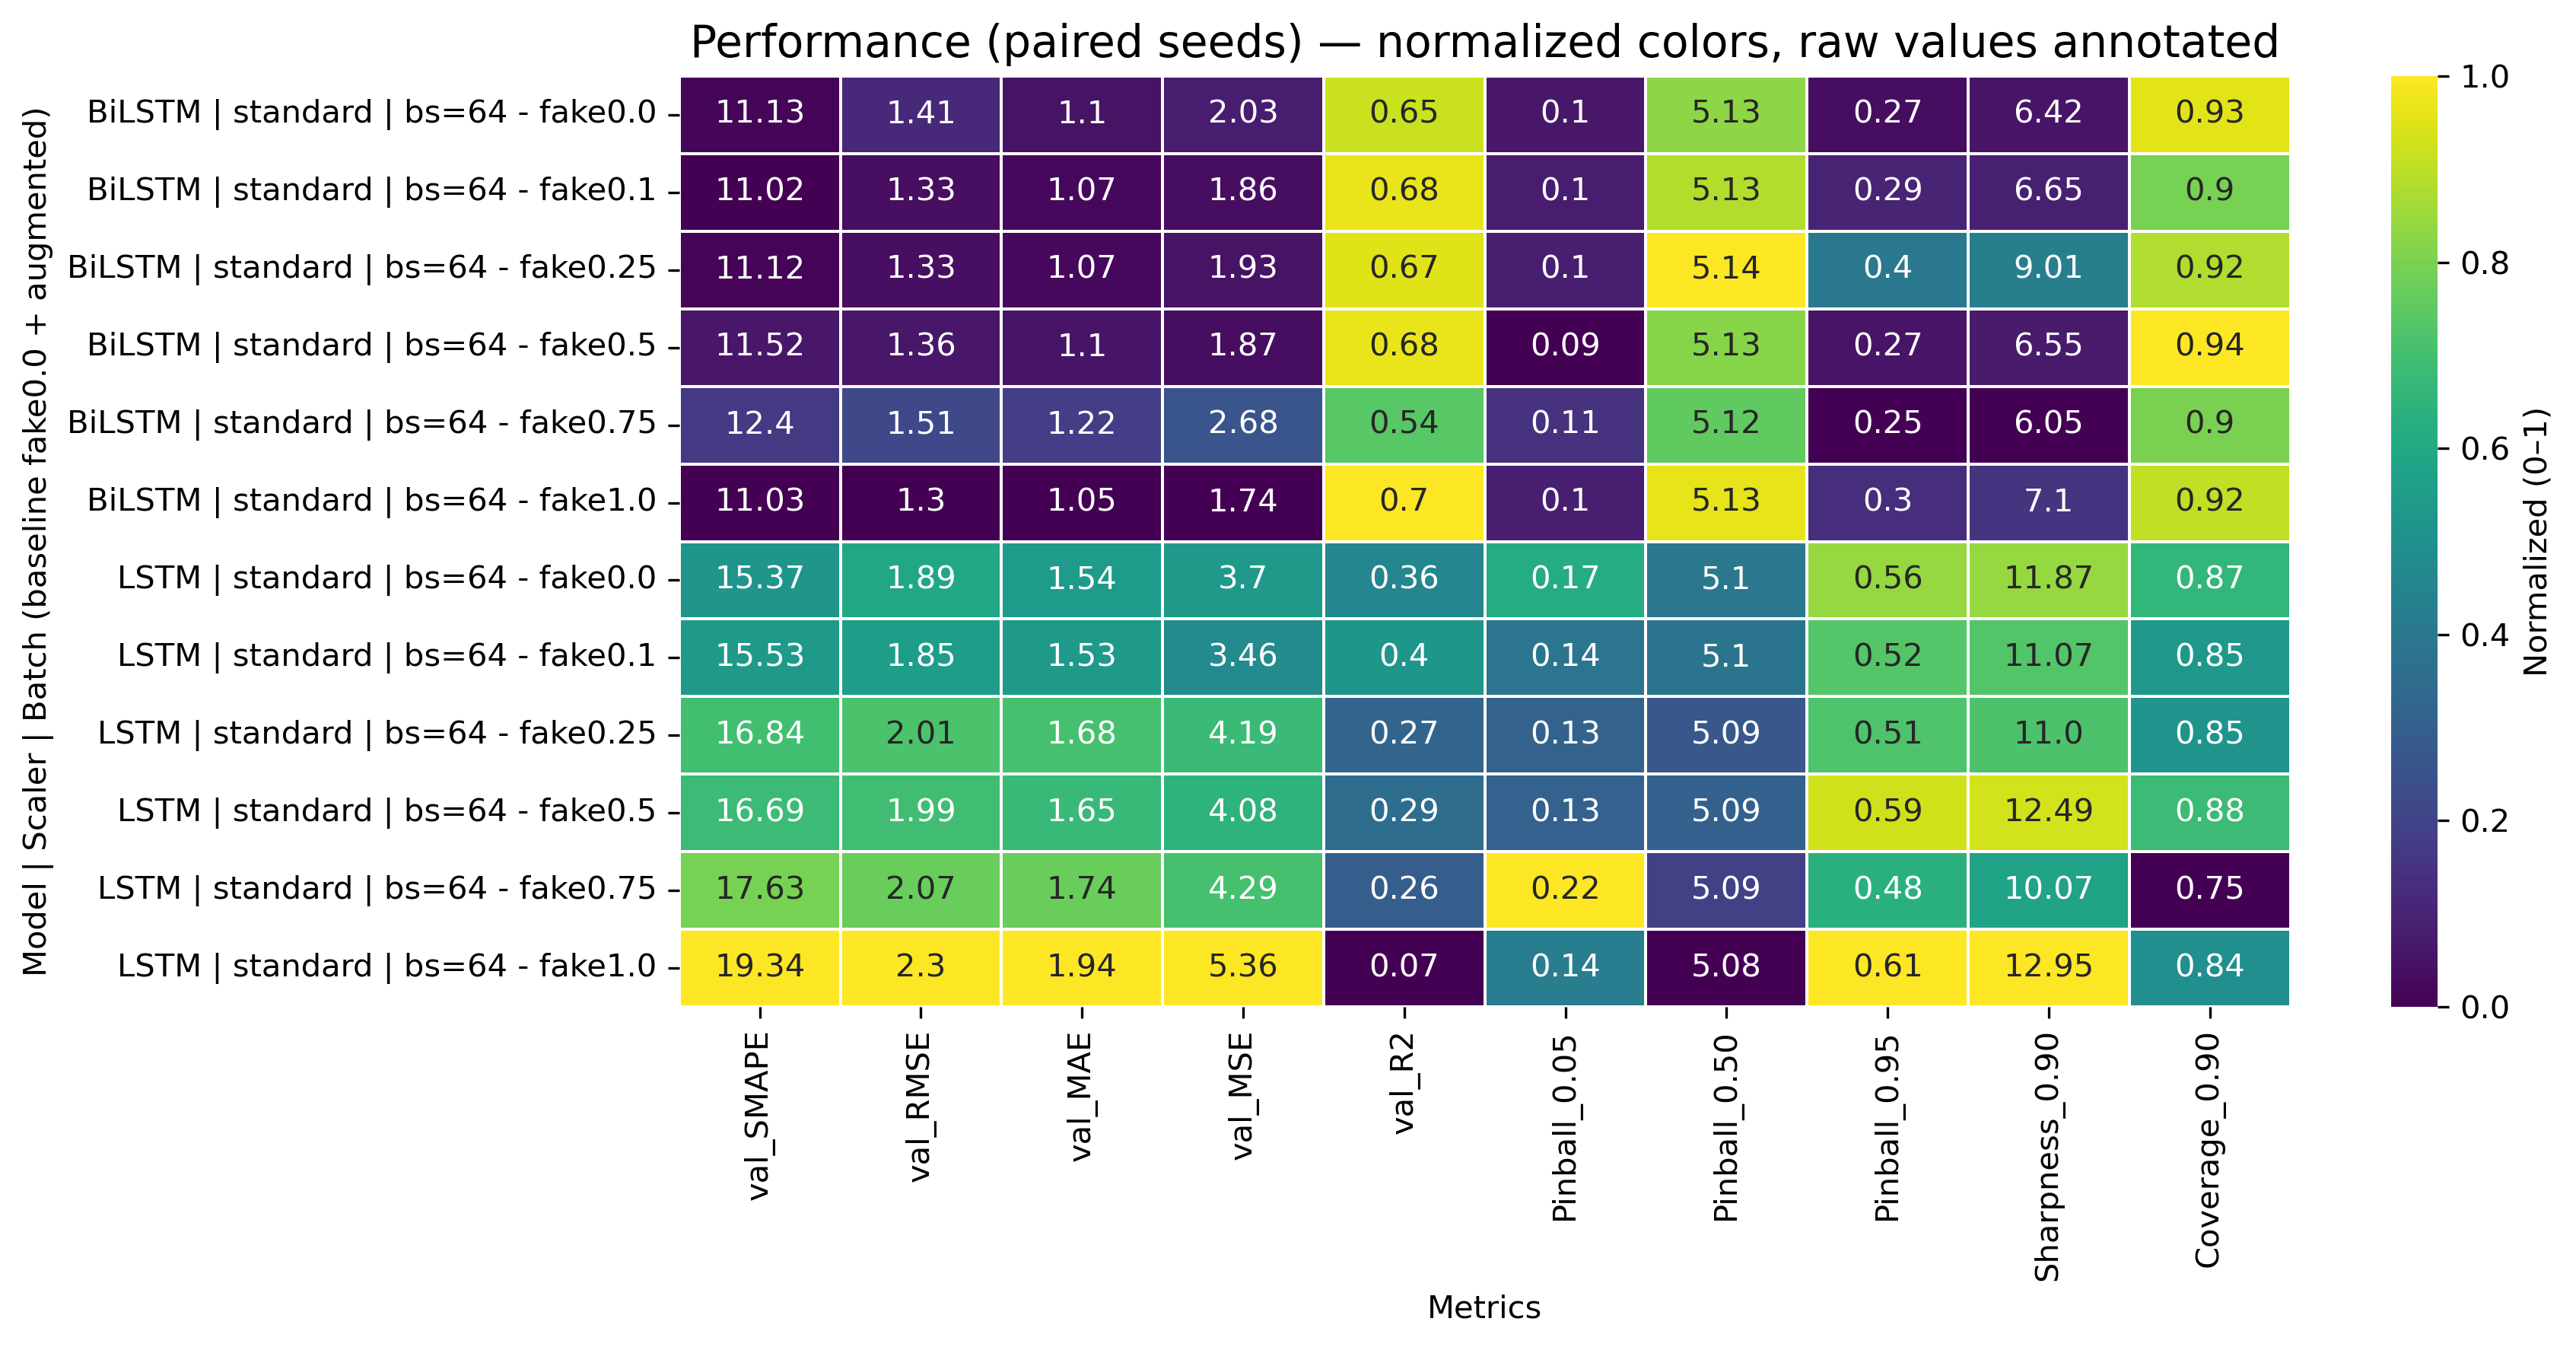

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# =========================
# Config
# =========================
# Include all metrics you want in the heatmap
METRICS = [
    'val_SMAPE','val_RMSE','val_MAE','val_MSE','val_R2',
    'Pinball_0.05','Pinball_0.50','Pinball_0.95',
    'Sharpness_0.90','Coverage_0.90'
]

# =========================
# Core (paired -> heatmap table)
# =========================
def build_heatmap_table_from_paired(paired: pd.DataFrame, metrics=METRICS):
    """
    Uses the paired DataFrame (aug joined to its baseline per seed) to produce:
      - baseline means over the same (paired) seeds
      - augmented means per fake_data_length over the same seeds
    Returns a DataFrame indexed by:
      "model | scaler | bs=... - fake{len}"
    with columns = metrics (raw means).
    """
    # Neat labels
    paired = paired.copy()
    paired['config_base_lbl'] = (
        paired['model_name'] + ' | ' + paired['scaler_name'] + ' | bs=' + paired['batch_size'].astype(str)
    )
    paired['config_full'] = paired['config_base_lbl'] + ' - fake' + paired['fake_data_length'].astype(str)

    # Augmented means (over paired seeds)
    aug_means = (
        paired.groupby('config_full')[metrics]
        .mean()
    )

    # Baseline means (over the exact same paired seeds)
    base_cols = {m: f'{m}_base' for m in metrics}
    base_means = (
        paired.groupby('config_base_lbl')[[base_cols[m] for m in metrics]]
        .mean()
        .rename(columns={f'{m}_base': m for m in metrics})
    )
    # Put baseline rows first as fake0.0
    base_means.index = base_means.index + ' - fake0.0'

    # Combine & sort
    heatmap_raw = pd.concat([base_means, aug_means], axis=0).sort_index()
    return heatmap_raw

def normalize_per_metric_minmax(df: pd.DataFrame) -> pd.DataFrame:
    """Column-wise min-max normalization (0..1). Leaves all-NaN columns as NaN."""
    norm = df.copy()
    for c in norm.columns:
        col = norm[c].astype(float)
        cmin, cmax = col.min(), col.max()
        if np.isfinite(cmin) and np.isfinite(cmax) and cmax != cmin:
            norm[c] = (col - cmin) / (cmax - cmin)
        else:
            norm[c] = np.nan  # avoids divide-by-zero colors
    return norm

def plot_paired_heatmap(
    paired: pd.DataFrame,
    metrics=METRICS,
    save_path="Plots/heatmap_augmentation_quantiles.png",
    cmap="viridis",
    dpi=300
):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    heatmap_data = build_heatmap_table_from_paired(paired, metrics=metrics)
    normalized = normalize_per_metric_minmax(heatmap_data)

    # Figure height scales with number of rows
    h = max(6, 0.45 * len(heatmap_data))
    plt.figure(figsize=(12, h), dpi=dpi)
    sns.heatmap(
        normalized,
        annot=heatmap_data.round(2),
        fmt='',
        cmap=cmap,
        linewidths=0.5,
        cbar_kws={'label': 'Normalized (0–1)'}
    )
    plt.title("Performance (paired seeds) — normalized colors, raw values annotated", fontsize=14)
    plt.xlabel("Metrics")
    plt.ylabel("Model | Scaler | Batch (baseline fake0.0 + augmented)")
    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    plt.show()

# =========================
# If you DON'T already have `paired`, build it from df + df_aug/df_test
# (Optional helper mirroring your augmentation pipeline)
# =========================
def build_paired_from_df(df_all: pd.DataFrame, metrics=METRICS) -> pd.DataFrame:
    """
    Filters to test-stage, pairs each augmented run with its baseline (same model, scaler, batch, seed).
    Returns 'paired' with both augmented columns and *_base columns.
    """
    df_all = df_all[df_all['testing_stage'] == True].copy()
    keys = ['model_name', 'scaler_name', 'batch_size', 'seed']

    base = df_all[df_all['data_augmentation'] == False][keys + metrics].copy()
    aug  = df_all[df_all['data_augmentation'] == True][keys + ['fake_data_length'] + metrics].copy()

    base = base.rename(columns={m: f'{m}_base' for m in metrics})
    paired = aug.merge(base, on=keys, how='inner', validate='many_to_one')
    return paired

# =========================
# Usage
# =========================
# EITHER: if you already have `paired` from your augmentation pipeline:
# plot_paired_heatmap(paired, metrics=METRICS, save_path="Plots/heatmap_augmentation_quantiles.png")

# OR: build `paired` on the fly from your full df and then plot:
paired = build_paired_from_df(df, metrics=METRICS)
plot_paired_heatmap(paired, metrics=METRICS, save_path="Plots/heatmap_augmentation_quantiles.png")


### Boxplots of the forecasters

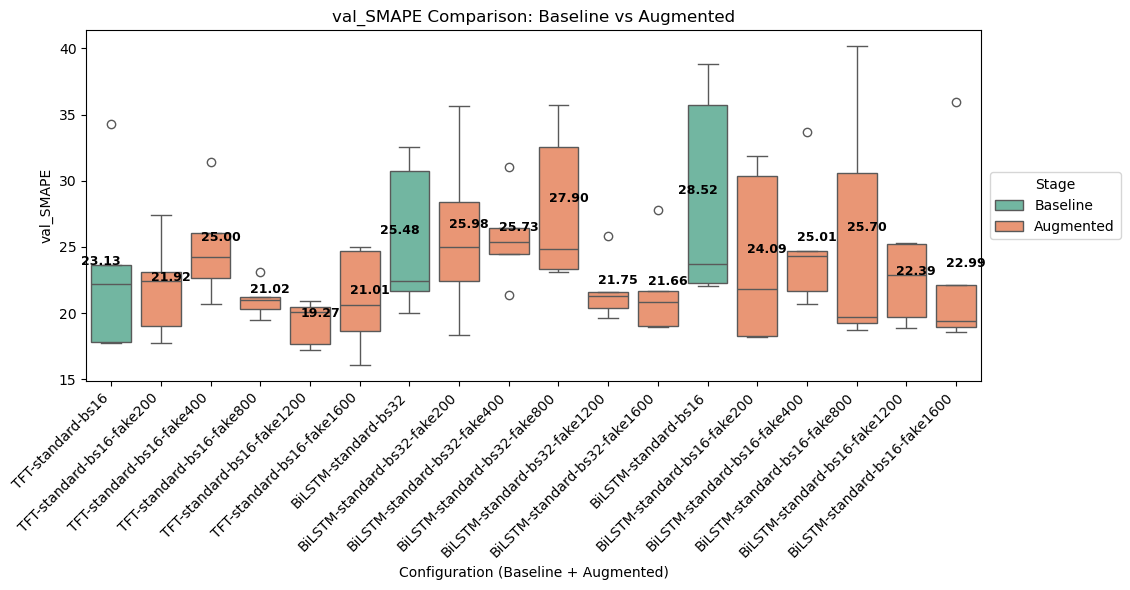

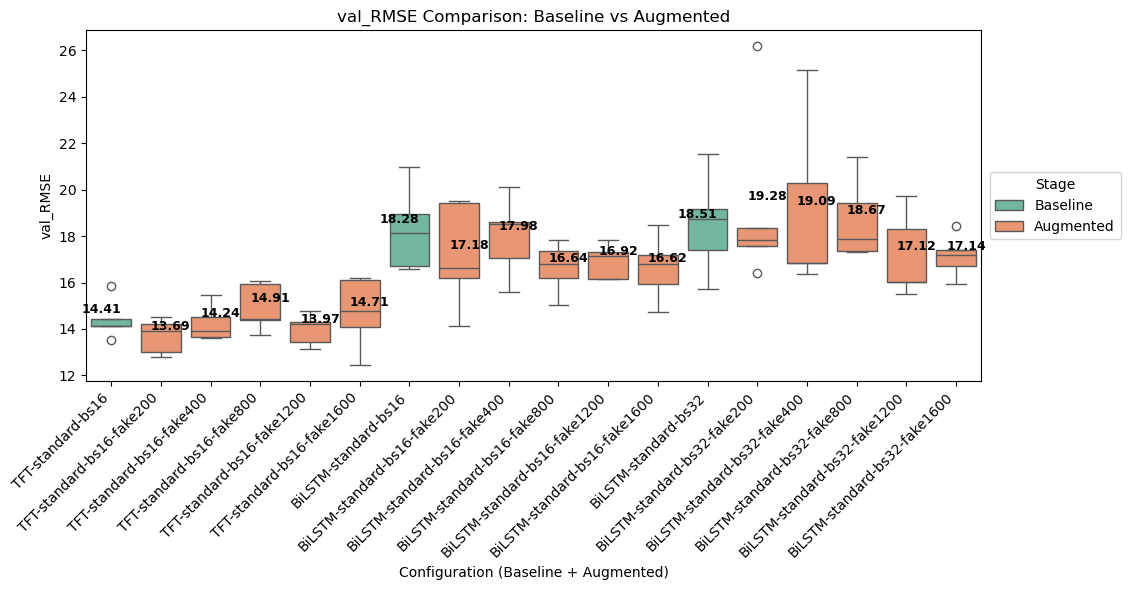

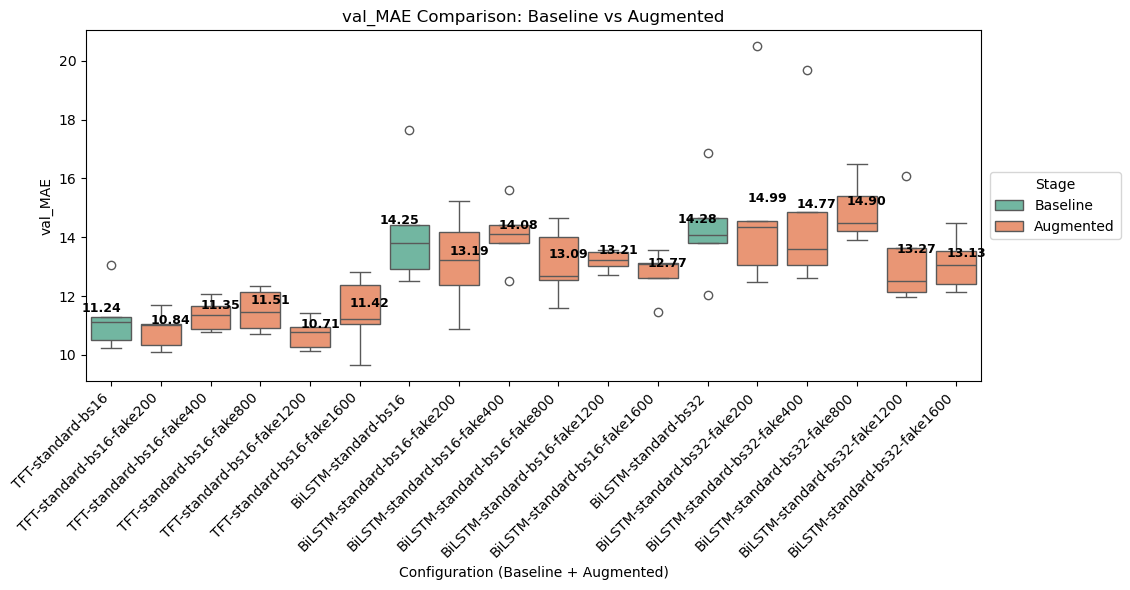

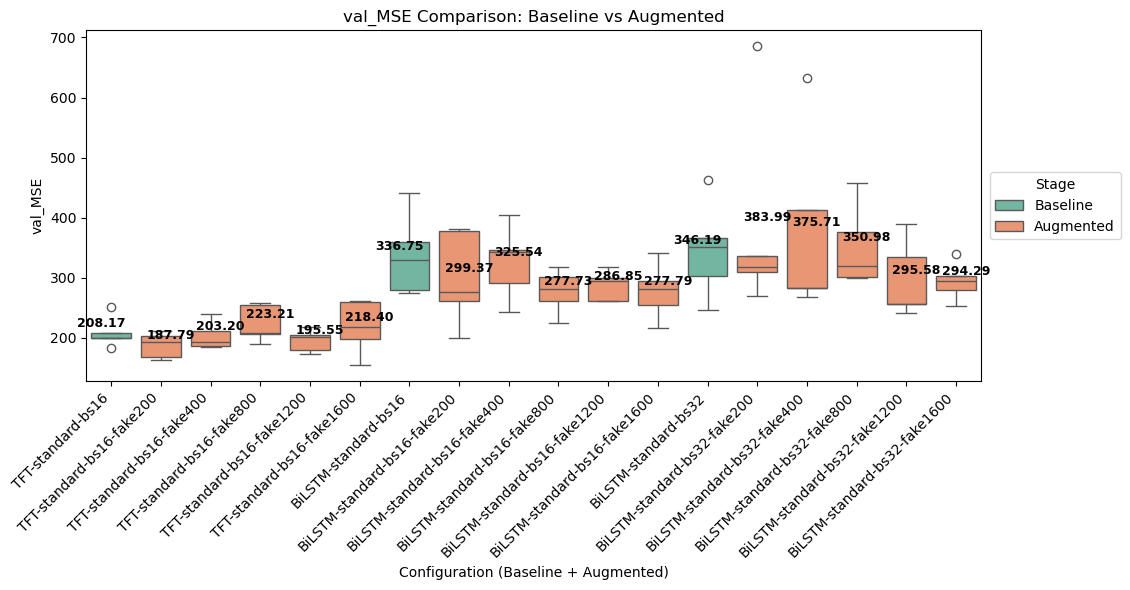

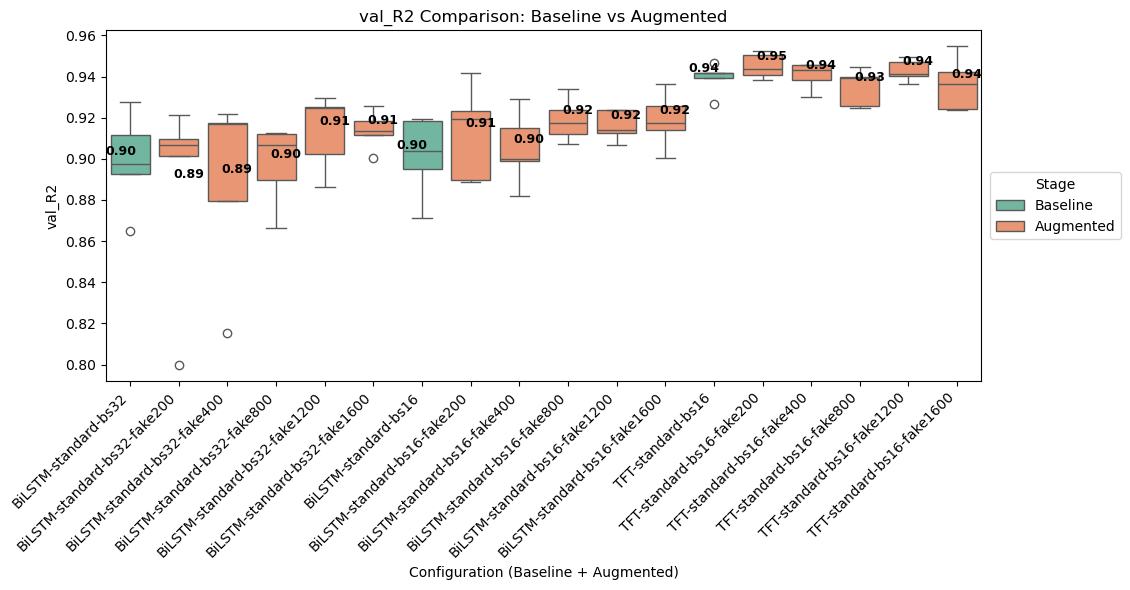

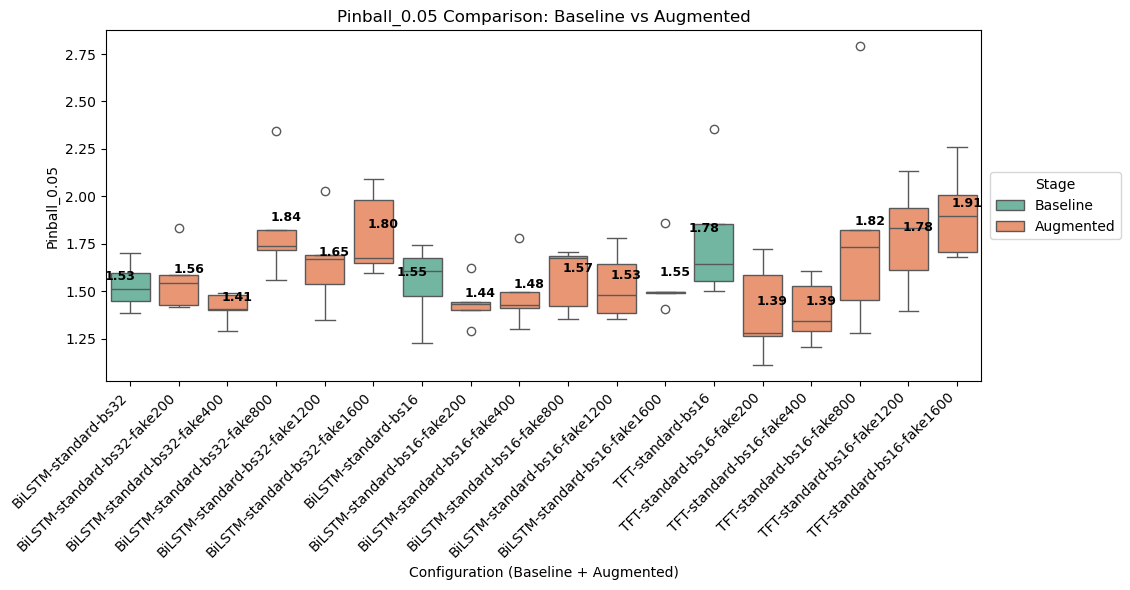

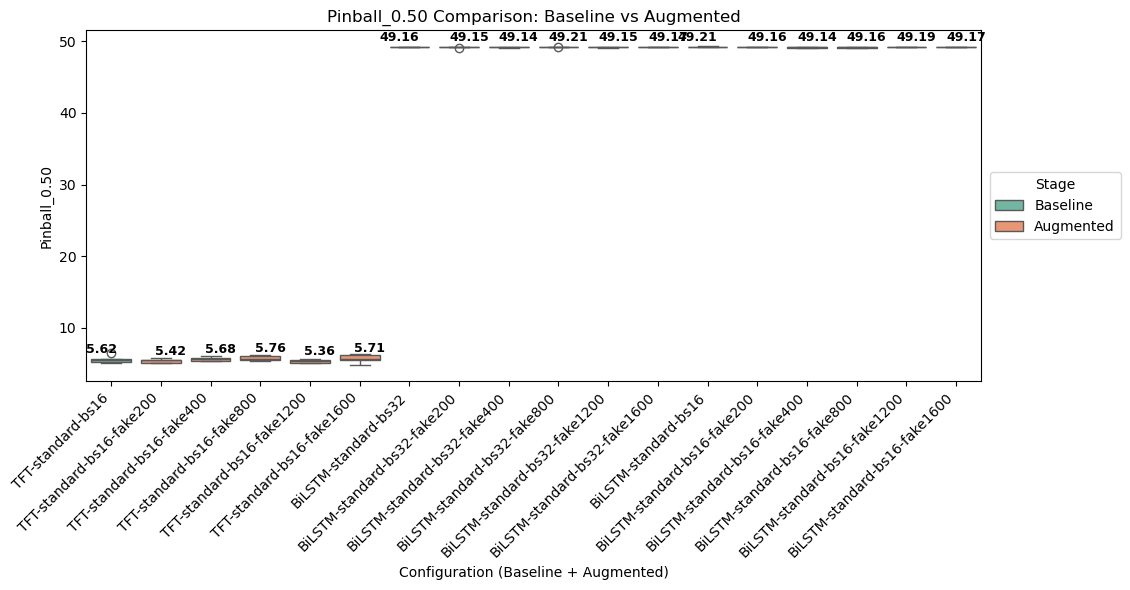

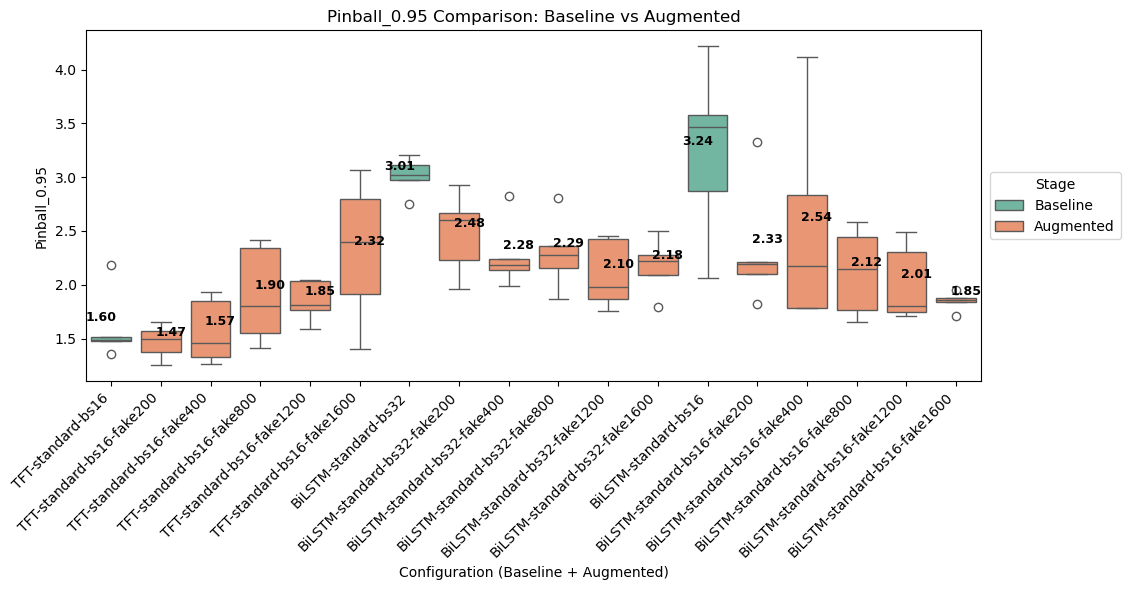

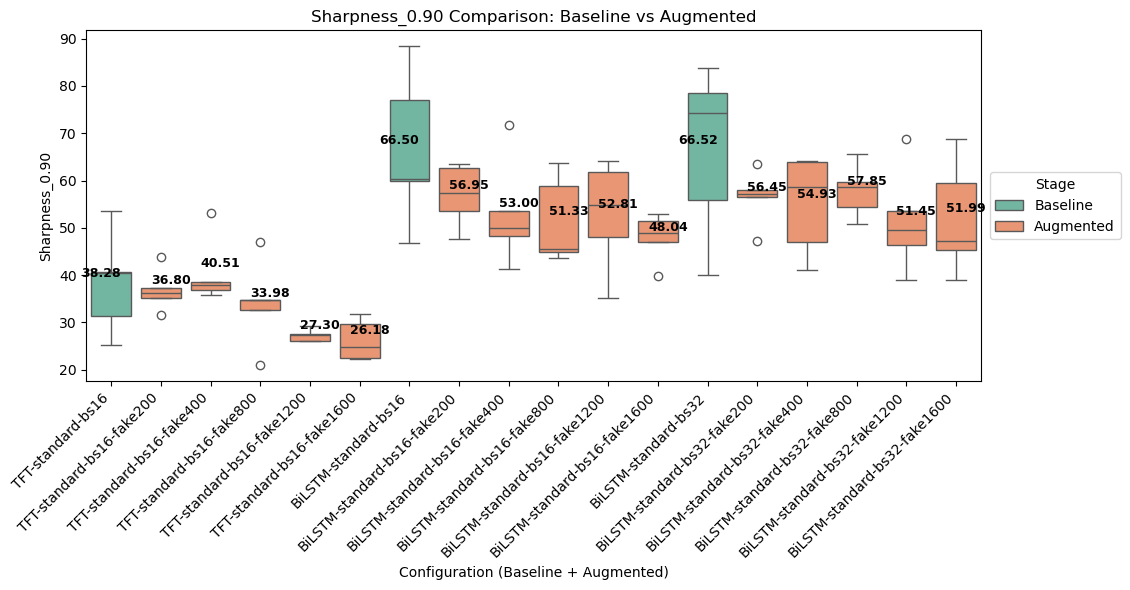

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_augmented_vs_baseline_boxplots(metric, df):
    # Create config_name: includes fake_data_length for augmented runs
    base = df['model_name'] + '-' + df['scaler_name'] + '-bs' + df['batch_size'].astype(str)
    augmented = df['data_augmentation'] & df['fake_data_length'].notna()
    df['config_name'] = base.where(~augmented, base + '-fake' + df['fake_data_length'].astype(str))

    # Add a new column: stage = 'Baseline' or 'Augmented'
    df['stage'] = df['data_augmentation'].apply(lambda x: 'Augmented' if x else 'Baseline')

    # Sort configs by baseline metric mean
    baseline_order = (
        df[df['stage'] == 'Baseline']
        .groupby('config_name')[metric]
        .mean()
        .sort_values()
        .index
    )

    # Include both baseline and augmented config names (in correct order)
    all_order = []
    for base_config in baseline_order:
        all_order.append(base_config)
        # Add all augmented variants of this config, sorted by fake_data_length
        variants = df[df['config_name'].str.startswith(base_config + '-fake')]['config_name'].unique()
        all_order.extend(sorted(variants, key=lambda x: int(x.split('fake')[-1])))

    # Plot
    plt.figure(figsize=(max(12, len(all_order) * 0.6), 6))
    ax = sns.boxplot(
        data=df[df['config_name'].isin(all_order)],
        x='config_name',
        y=metric,
        hue='stage',
        order=all_order,
        palette='Set2'
    )

    # Annotate mean values
    grouped = df.groupby(['config_name', 'stage'])[metric].mean()
    offsets = {'Baseline': -0.2, 'Augmented': 0.2}
    for i, config in enumerate(all_order):
        for stage in ['Baseline', 'Augmented']:
            if (config, stage) in grouped:
                mean_val = grouped[(config, stage)]
                ax.text(
                    i + offsets[stage],
                    mean_val + 0.01 * (df[metric].max() - df[metric].min()),
                    f"{mean_val:.2f}",
                    ha='center', va='bottom', fontsize=9,
                    color='black', fontweight='bold'
                )

    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Configuration (Baseline + Augmented)")
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison: Baseline vs Augmented")
    plt.legend(
        title="Stage",
        loc='center left',
        bbox_to_anchor=(1.01, 0.5),  # pushes it fully outside to the right
        borderaxespad=0.
    )
    plt.tight_layout(rect=[0, 0, 0.95, 1])  # leave room for legend on the right
    plt.savefig(f"Plots/boxplot_{metric}_pinball_augmentation.png")

df_combined = pd.concat([df_test, df_aug], axis=0, ignore_index=True)
metrics = ['val_SMAPE', 'val_RMSE', 'val_MAE', 'val_MSE', 'val_R2', 'Pinball_0.05', 'Pinball_0.50', 'Pinball_0.95', 'Sharpness_0.90']
for metric in metrics:
    plot_augmented_vs_baseline_boxplots(metric, df)